# CBM Predictor — XAI Analysis (v2 Architecture)

Bu notebook, **v2 üç-branch mimarisine** tam uyumlu XAI analizleri sağlar:
- **Branch 1:** GNN (6 katman CGConv, hidden=256, out=192, 16-dim RBF edge)
- **Branch 2:** TDA (topological descriptors → 128 dim)
- **Branch 3:** MEGNet Embeddings (→ 64 dim)

| Bölüm | Yöntem | Soru |
|-------|--------|------|
| 1 | **GNNExplainer** | Hangi atom/bağ tahmine katkı sağladı? |
| 2 | **Integrated Gradients** | Hangi node feature en önemli? |
| 3 | **Eleman İstatistikleri** | Hangi elementler CBM'yi yukarı/aşağı iter? |
| 4 | **Hata Analizi** | Model nerede başarısız? |
| 5 | **EMB Branch Analizi** | Embedding branch ne katkı sağlıyor? |
| 6 | **Literatür Görselleri** | 10 ek yayın kalitesi grafik |

**v2 Farkları:**
- Edge features: 4-dim sabit → **16-dim Gaussian RBF**
- GNN: 4 → **6 katman**, hidden 160 → **256**, out 128 → **192**
- TDA projection: 64 → **128** dim
- MEGNet projection: 32 → **64** dim
- FUSION_DIM: 224 → **384**
- CPPN K: 4 → **6**, cubic branch eklendi
- Cache dizini: `./cache` → `./cache_v2`
- Model dosyası: `model_best.pt` → `model_best_v2.pt`

**Gereksinimler:**
```bash
pip install torch torch-geometric pymatgen scikit-learn pandas numpy matplotlib seaborn captum umap-learn scipy
```


In [1]:
import subprocess, sys
for p in ['captum','seaborn','umap-learn','scipy']:
    try: __import__(p.replace('-','_'))
    except ImportError:
        print(f'Installing {p}...')
        subprocess.run([sys.executable,'-m','pip','install',p,'-q'])
print('All packages ready.')


Installing umap-learn...
All packages ready.


In [2]:
import sys, warnings, math
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict
from scipy.stats import gaussian_kde

from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool
from torch_geometric.explain import Explainer, GNNExplainer
from pymatgen.core import Structure
from pymatgen.core.periodic_table import Element
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


## ⚙️ Configuration

In [3]:
# ── PATHS — edit here ─────────────────────────────────────
MODEL_PATH   = 'model_best_v2.pt'
CACHE_DIR    = Path('./cache_v2')
CIF_DIR      = Path('./cif')
LABELS_CSV   = 'labels.csv'
PRED_CSV     = 'predictions.csv'
EMB_CSV      = 'embeddings.csv'     # MEGNet embeddings
TDA_SCALER   = CACHE_DIR / 'tda_scaler.pkl'
N_EXPLAIN    = 20
N_WORST      = 30
ELEM_SAMPLE_SIZE = 5000
# ───────────────────────────────────────────────────────────

# Must match cbm_predictor_v2.py
import torch
CUTOFF_RADIUS   = 6.0
TDA_BINS        = 16
TDA_DIM         = TDA_BINS * 2          # 32
MEGNET_EMB_DIM  = 16
MEGNET_PROJ_DIM = 64                    # v2: 32→64
NODE_FEAT_DIM   = 7
RBF_COUNT       = 16                    # v2: 16 Gaussian RBF edge features
EDGE_FEAT_DIM   = RBF_COUNT
RBF_CENTERS     = torch.linspace(0.0, 1.0, RBF_COUNT)
RBF_GAMMA       = (RBF_COUNT / 2.0) ** 2
GNN_LAYERS      = 6                     # v2: 4→6
GNN_HIDDEN      = 256                   # v2: 160→256
GNN_OUT         = 192                   # v2: 128→192
TDA_PROJ_DIM    = 128                   # v2: 64→128
FUSION_DIM      = GNN_OUT + TDA_PROJ_DIM + MEGNET_PROJ_DIM  # 192+128+64=384
CPPN_K          = 6                     # v2: 4→6

ELEMENT_ATTRS = ['atomic_mass','atomic_radius','X','ionization_energy',
                 'electron_affinity','row','group']
FEAT_NAMES    = ELEMENT_ATTRS
BRANCH_DIMS   = {'GNN': GNN_OUT, 'TDA': TDA_PROJ_DIM, 'MEGNet': MEGNET_PROJ_DIM}
BRANCH_SLICES = {
    'GNN':    (0,               GNN_OUT),
    'TDA':    (GNN_OUT,         GNN_OUT+TDA_PROJ_DIM),
    'MEGNet': (GNN_OUT+TDA_PROJ_DIM, FUSION_DIM),
}


## 📦 Model Tanımları (v2 — RBF-16 edges, 6-layer GNN, K=6 CPPN)


In [4]:
_ELEM_NORM = {
    'atomic_mass':       (60.0, 60.0),
    'atomic_radius':     (1.5,  0.5),
    'X':                 (2.0,  0.8),
    'ionization_energy': (8.0,  3.0),
    'electron_affinity': (1.5,  1.5),
    'row':               (3.5,  1.5),
    'group':             (9.0,  5.5),
}
_ELEM_CACHE = {}

def elem_feat(symbol):
    if symbol not in _ELEM_CACHE:
        try:
            el = Element(symbol)
            feats = []
            for a in ELEMENT_ATTRS:
                val = float(getattr(el, a, None) or 0.0)
                mu, sigma = _ELEM_NORM[a]
                feats.append((val - mu) / sigma)
        except:
            feats = [0.0] * 7
        _ELEM_CACHE[symbol] = np.clip(np.array(feats, dtype=np.float32), -3.0, 3.0)
    return _ELEM_CACHE[symbol]

# Load & normalize MEGNet embeddings
_MEGNET_EMB    = {}
_MEGNET_ZERO   = np.zeros(MEGNET_EMB_DIM, dtype=np.float32)
_MEGNET_SCALER = None

def load_megnet_embeddings(csv_path):
    global _MEGNET_EMB, _MEGNET_ZERO, _MEGNET_SCALER
    df = pd.read_csv(csv_path)
    id_col = next((c for c in ['material_id','mp_id','id'] if c in df.columns), None)
    if id_col is None: raise ValueError(f'No ID column found. Columns: {list(df.columns)}')
    emb_cols = [c for c in df.columns if c != id_col]
    mat = np.nan_to_num(df[emb_cols].values.astype(np.float32))
    _MEGNET_SCALER = StandardScaler()
    mat_norm = np.clip(_MEGNET_SCALER.fit_transform(mat), -3.0, 3.0)
    for mid, vec in zip(df[id_col].astype(str).str.strip(), mat_norm):
        _MEGNET_EMB[mid] = vec.astype(np.float32)
    print(f'Loaded {len(_MEGNET_EMB)} embeddings | '
          f'mean={mat_norm.mean():.3f}  std={mat_norm.std():.3f}')

def get_megnet_emb(filename):
    return _MEGNET_EMB.get(filename.replace('.cif','').strip(), _MEGNET_ZERO)


def rbf_encode(dist: float) -> list:
    """Mesafeyi 16 Gaussian RBF ile encode et (v2 — zengin edge repr.)."""
    d_norm = dist / CUTOFF_RADIUS          # [0, 1]
    centers = RBF_CENTERS.numpy()
    return np.exp(-RBF_GAMMA * (d_norm - centers) ** 2).tolist()


def cif_to_data(cif_path, tda_scaler=None, filename=''):
    """CIF → PyG Data  (v2: 16-dim RBF edge features, separate megnet attr)."""
    struct = Structure.from_file(str(cif_path))
    symbols = [str(s.specie.symbol) for s in struct]
    x = torch.tensor(np.array([elem_feat(s) for s in symbols], dtype=np.float32))

    all_nbrs = struct.get_all_neighbors(CUTOFF_RADIUS, include_index=True)
    src_l, dst_l, attr_l = [], [], []
    for i, nbrs in enumerate(all_nbrs):
        for nbr in sorted(nbrs, key=lambda n: n[1])[:12]:
            j, dist = nbr[2], nbr[1]
            attr_l.append(rbf_encode(dist))   # 16-dim RBF (v2)
            src_l.append(i); dst_l.append(j)

    tda = np.zeros(TDA_DIM, dtype=np.float32)
    if tda_scaler is not None:
        tda = np.clip(np.nan_to_num(tda_scaler.transform(tda.reshape(1,-1))[0]), -5, 5)

    fname = Path(cif_path).name if not filename else filename
    megnet_vec = get_megnet_emb(fname)

    data = Data(
        x=x,
        edge_index=torch.tensor([src_l, dst_l], dtype=torch.long),
        edge_attr=torch.tensor(attr_l, dtype=torch.float),   # (E, 16)
        tda=torch.tensor(tda, dtype=torch.float),
        megnet=torch.tensor(megnet_vec, dtype=torch.float),
        symbols=symbols
    )
    return data, symbols


class GNNEncoder(nn.Module):
    """6 katman CGConv, hidden=256, out=192 (v2)."""
    def __init__(self, node_dim, edge_dim, hidden, out_dim, n_layers=GNN_LAYERS):
        super().__init__()
        self.input_proj  = nn.Linear(node_dim, hidden)
        self.convs  = nn.ModuleList([CGConv(hidden, dim=edge_dim, batch_norm=False) for _ in range(n_layers)])
        self.norms  = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(n_layers)])
        self.output_proj = nn.Linear(hidden, out_dim)
        self.act = nn.SiLU()
        for layer in [self.input_proj, self.output_proj]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
    def forward(self, x, edge_index, edge_attr, batch):
        h = self.act(self.input_proj(x))
        h = F.dropout(h, p=0.1, training=self.training)
        for conv, norm in zip(self.convs, self.norms):
            h = norm(self.act(conv(h, edge_index, edge_attr)) + h)
            h = F.dropout(h, p=0.1, training=self.training)
        return self.output_proj(global_mean_pool(h, batch))


class TDAProjector(nn.Module):
    """TDA histogram → 128 dim (v2: 64→128, +1 ara katman)."""
    def __init__(self, in_dim=TDA_DIM, out_dim=TDA_PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim * 2), nn.SiLU(),
            nn.LayerNorm(out_dim * 2),
            nn.Dropout(0.1),
            nn.Linear(out_dim * 2, out_dim * 2), nn.SiLU(),
            nn.LayerNorm(out_dim * 2),
            nn.Linear(out_dim * 2, out_dim),
        )
    def forward(self, z): return self.net(z)


class MEGNetProjector(nn.Module):
    """MEGNet embedding → 64 dim (v2: 32→64, +1 ara katman)."""
    def __init__(self, in_dim=MEGNET_EMB_DIM, out_dim=MEGNET_PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim * 2), nn.SiLU(),
            nn.LayerNorm(out_dim * 2),
            nn.Dropout(0.1),
            nn.Linear(out_dim * 2, out_dim * 2), nn.SiLU(),
            nn.LayerNorm(out_dim * 2),
            nn.Linear(out_dim * 2, out_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                nn.init.zeros_(m.bias)
    def forward(self, z): return self.net(z)


class CPPNHead(nn.Module):
    """
    ŷ = Σₖ gₖ(z) · Pₖ(z)  — K=6 mixture, daha derin poly branches (v2).
    [BUG FIX v1]: gradient_penalty z.detach() KALDIRILDI → backprop çalışır.
    """
    def __init__(self, in_dim=FUSION_DIM, K=CPPN_K):
        super().__init__()
        self.K = K
        self.gate = nn.Sequential(
            nn.Linear(in_dim, K * 8), nn.SiLU(),
            nn.LayerNorm(K * 8),
            nn.Linear(K * 8, K * 4), nn.SiLU(),
            nn.Linear(K * 4, K)
        )
        mid = in_dim // 2
        self.poly_lin = nn.ModuleList([nn.Linear(in_dim, 1) for _ in range(K)])
        self.poly_q1  = nn.ModuleList([nn.Linear(in_dim, mid) for _ in range(K)])
        self.poly_q2  = nn.ModuleList([nn.Linear(mid, 1) for _ in range(K)])
        self.poly_c1  = nn.ModuleList([nn.Linear(in_dim, mid // 2) for _ in range(K)])  # cubic
        self.poly_c2  = nn.ModuleList([nn.Linear(mid // 2, 1) for _ in range(K)])
    def forward(self, z):
        gates = F.softmax(self.gate(z), dim=-1)
        preds = torch.cat([
            self.poly_lin[k](z)
            + self.poly_q2[k](F.silu(self.poly_q1[k](z)))
            + self.poly_c2[k](F.silu(self.poly_c1[k](z)).pow(2))   # cubic term (v2)
            for k in range(self.K)
        ], dim=-1)
        return (gates * preds).sum(dim=-1)


class CBMPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.gnn         = GNNEncoder(NODE_FEAT_DIM, EDGE_FEAT_DIM, GNN_HIDDEN, GNN_OUT)
        self.tda_proj    = TDAProjector(TDA_DIM, TDA_PROJ_DIM)
        self.megnet_proj = MEGNetProjector(MEGNET_EMB_DIM, MEGNET_PROJ_DIM)
        self.norm        = nn.LayerNorm(FUSION_DIM)
        self.head        = CPPNHead(FUSION_DIM, K=CPPN_K)

    def forward(self, batch):
        tda    = torch.nan_to_num(batch.tda.view(batch.num_graphs,-1),    nan=0., posinf=3., neginf=-3.)
        megnet = torch.nan_to_num(batch.megnet.view(batch.num_graphs,-1), nan=0., posinf=3., neginf=-3.)
        x_in   = torch.nan_to_num(batch.x,          nan=0., posinf=3., neginf=-3.)
        ea_in  = torch.nan_to_num(batch.edge_attr,   nan=0., posinf=1., neginf=0.)
        z_gnn  = torch.nan_to_num(self.gnn(x_in, batch.edge_index, ea_in, batch.batch))
        z_tda  = torch.nan_to_num(self.tda_proj(tda))
        z_meg  = torch.nan_to_num(self.megnet_proj(megnet))
        z      = self.norm(torch.cat([z_gnn, z_tda, z_meg], dim=-1))
        return self.head(z), z

    def forward_branches(self, batch):
        """Returns (pred, z_full, z_gnn, z_tda, z_meg) for branch analysis."""
        tda    = torch.nan_to_num(batch.tda.view(batch.num_graphs,-1),    nan=0., posinf=3., neginf=-3.)
        megnet = torch.nan_to_num(batch.megnet.view(batch.num_graphs,-1), nan=0., posinf=3., neginf=-3.)
        x_in   = torch.nan_to_num(batch.x,        nan=0., posinf=3., neginf=-3.)
        ea_in  = torch.nan_to_num(batch.edge_attr, nan=0., posinf=1., neginf=0.)
        z_gnn  = torch.nan_to_num(self.gnn(x_in, batch.edge_index, ea_in, batch.batch))
        z_tda  = torch.nan_to_num(self.tda_proj(tda))
        z_meg  = torch.nan_to_num(self.megnet_proj(megnet))
        z      = self.norm(torch.cat([z_gnn, z_tda, z_meg], dim=-1))
        return self.head(z), z, z_gnn, z_tda, z_meg


# ── Wrappers ──────────────────────────────────────────────────────────────────
class ModelWrapper(nn.Module):
    """GNNExplainer wrapper — fixes tda + megnet, exposes x/edge_index interface."""
    def __init__(self, model, tda_tensor, megnet_tensor):
        super().__init__()
        self.model  = model
        self.tda    = tda_tensor
        self.megnet = megnet_tensor
    def forward(self, x, edge_index, edge_attr=None, batch=None):
        if batch is None:
            batch = torch.zeros(x.shape[0], dtype=torch.long, device=x.device)
        tda    = self.tda.to(x.device).unsqueeze(0)
        megnet = self.megnet.to(x.device).unsqueeze(0)
        x_in   = torch.nan_to_num(x, nan=0., posinf=3., neginf=-3.)
        ea_in  = torch.nan_to_num(edge_attr, nan=0., posinf=1., neginf=0.) if edge_attr is not None else edge_attr
        z_gnn  = self.model.gnn(x_in, edge_index, ea_in, batch)
        z_tda  = self.model.tda_proj(tda)
        z_meg  = self.model.megnet_proj(megnet)
        z      = self.model.norm(torch.cat([torch.nan_to_num(z_gnn),
                                            torch.nan_to_num(z_tda),
                                            torch.nan_to_num(z_meg)], dim=-1))
        return self.model.head(z).unsqueeze(-1)


class CaptumWrapper(nn.Module):
    """Captum IG wrapper — only x is the input tensor; rest is fixed."""
    def __init__(self, model, fixed_batch):
        super().__init__()
        self.model = model
        self.batch = fixed_batch
    def forward(self, x):
        b      = self.batch
        tda    = torch.nan_to_num(b.tda.view(1,-1).to(x.device),    nan=0., posinf=3., neginf=-3.)
        megnet = torch.nan_to_num(b.megnet.view(1,-1).to(x.device), nan=0., posinf=3., neginf=-3.)
        ea_in  = torch.nan_to_num(b.edge_attr.to(x.device), nan=0., posinf=1., neginf=0.)
        bidx   = torch.zeros(x.shape[0], dtype=torch.long, device=x.device)
        z_gnn  = self.model.gnn(x, b.edge_index.to(x.device), ea_in, bidx)
        z_tda  = self.model.tda_proj(tda)
        z_meg  = self.model.megnet_proj(megnet)
        z      = self.model.norm(torch.cat([torch.nan_to_num(z_gnn),
                                            torch.nan_to_num(z_tda),
                                            torch.nan_to_num(z_meg)], dim=-1))
        return self.model.head(z)


print('Model classes defined (v2 — six-layer GNN, RBF-16 edges, K=6 CPPN).')


Model classes defined (v4 three-branch).


In [5]:
model = CBMPredictor().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded: {MODEL_PATH}  |  Parameters: {n_params:,}')

tda_scaler = joblib.load(TDA_SCALER) if TDA_SCALER.exists() else None
print(f'TDA scaler: {"loaded" if tda_scaler else "not found"}')

# Load MEGNet embeddings
if Path(EMB_CSV).exists():
    load_megnet_embeddings(EMB_CSV)
else:
    print(f'WARNING: {EMB_CSV} not found — embedding branch will use zero vectors')

df_labels = pd.read_csv(LABELS_CSV)
df_labels['material_id'] = df_labels['filename'].str.replace('.cif','',regex=False)
print(f'Labels: {len(df_labels):,}')


Model loaded: model_best.pt  |  Parameters: 561,468
TDA scaler: loaded
Loaded 63106 embeddings | mean=-0.008  std=0.904
Labels: 63,106


In [6]:
pred_path = Path(PRED_CSV)
if pred_path.exists():
    df_pred = pd.read_csv(pred_path)
    df_pred['abs_error']    = np.abs(df_pred['cbm_pred'] - df_pred['cbm_true'])
    df_pred['signed_error'] = df_pred['cbm_pred'] - df_pred['cbm_true']
    mae = mean_absolute_error(df_pred['cbm_true'], df_pred['cbm_pred'])
    r2  = r2_score(df_pred['cbm_true'], df_pred['cbm_pred'])
    print(f'Predictions loaded: {len(df_pred):,}  |  MAE={mae:.4f} eV  R²={r2:.4f}')
    print(df_pred.head())
else:
    print(f'{PRED_CSV} not found — run cbm_predictor.py first')
    df_pred = None


Predictions loaded: 59,891  |  MAE=0.3980 eV  R²=0.9303
     filename  cbm_true  cbm_pred     error  split  abs_error  signed_error
0  mp-1182566    0.0056  1.324897  1.319297  train   1.319297      1.319297
1  mp-1024067    3.2834  3.342588  0.059188  train   0.059188      0.059188
2  mp-1246171    3.8661  3.899718  0.033618  train   0.033618      0.033618
3   mp-757580    5.6260  5.360362  0.265638  train   0.265638     -0.265638
4   mp-780652    1.1540  1.205029  0.051029   test   0.051029      0.051029


---
## 📊 Section 4 — Error Analysis
> *Run this first — identifies which materials are interesting for deeper analysis.*

In [7]:
if df_pred is not None:
    if 'split' in df_pred.columns:
        for split, grp in df_pred.groupby('split'):
            m = mean_absolute_error(grp['cbm_true'], grp['cbm_pred'])
            r = r2_score(grp['cbm_true'], grp['cbm_pred'])
            print(f'  {split:5s} → MAE:{m:.4f} eV  R²:{r:.4f}  (n={len(grp):,})')


  test  → MAE:0.5121 eV  R²:0.8773  (n=8,984)
  train → MAE:0.3531 eV  R²:0.9501  (n=41,923)
  val   → MAE:0.4933 eV  R²:0.8908  (n=8,984)


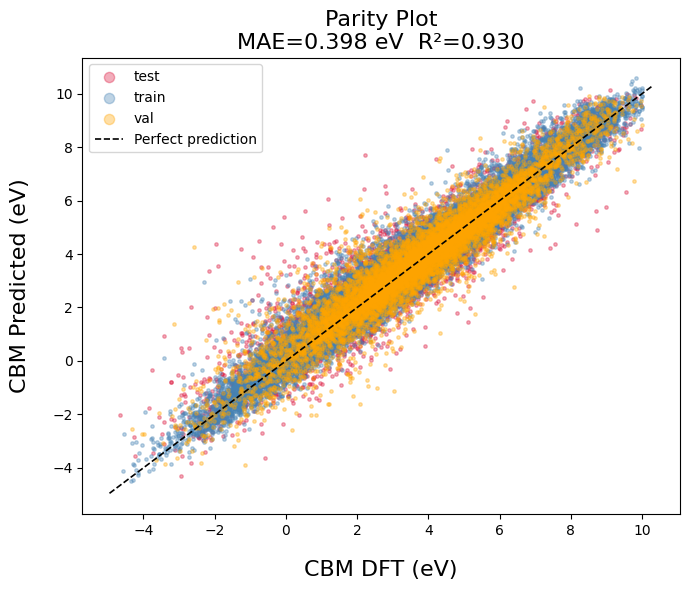

Saved: xai_parity.png


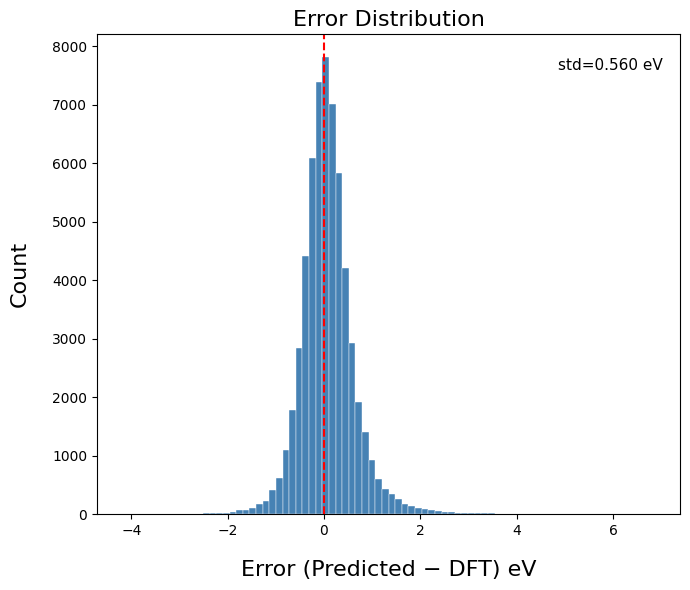

Saved: xai_error_dist.png


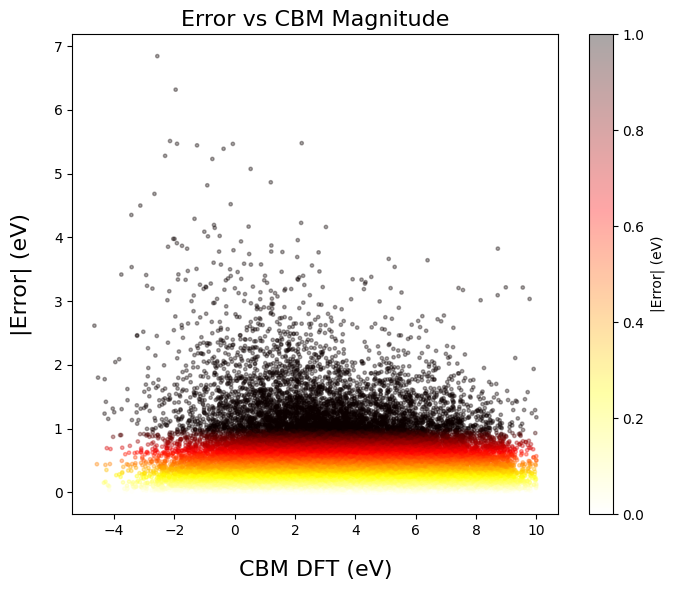

Saved: xai_error_vs_cbm.png


In [8]:
if df_pred is not None:
    # Fig 1: Parity + Error distribution + Error vs CBM
    for title, xlabel, ylabel, plot_fn, fname in [
        ('Parity Plot', 'CBM DFT (eV)', 'CBM Predicted (eV)', 'parity', 'xai_parity.png'),
        ('Error Distribution', 'Error (Predicted − DFT) eV', 'Count', 'hist', 'xai_error_dist.png'),
        ('Error vs CBM Magnitude', 'CBM DFT (eV)', '|Error| (eV)', 'scatter', 'xai_error_vs_cbm.png'),
    ]:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(7, 6))
        if plot_fn == 'parity':
            colors = {'train':'steelblue','val':'orange','test':'crimson'}
            if 'split' in df_pred.columns:
                for s, g in df_pred.groupby('split'):
                    ax.scatter(g['cbm_true'], g['cbm_pred'], s=6, alpha=0.35,
                               label=s, c=colors.get(s,'gray'))
            else:
                ax.scatter(df_pred['cbm_true'], df_pred['cbm_pred'], s=6, alpha=0.35)
            lim = [df_pred['cbm_true'].min()-0.3, df_pred['cbm_true'].max()+0.3]
            ax.plot(lim, lim, 'k--', lw=1.2, label='Perfect prediction')
            ax.legend(markerscale=3)
            ax.set_title(f'{title}\nMAE={mae:.3f} eV  R²={r2:.3f}', fontsize=16)
        elif plot_fn == 'hist':
            ax.hist(df_pred['signed_error'], bins=80, color='steelblue',
                    edgecolor='white', lw=0.3)
            ax.axvline(0, color='red', lw=1.5, ls='--')
            ax.text(0.97, 0.95, f'std={df_pred["signed_error"].std():.3f} eV',
                    transform=ax.transAxes, ha='right', va='top', fontsize=11)
            ax.set_title(title, fontsize=16)
        else:
            sc = ax.scatter(df_pred['cbm_true'], df_pred['abs_error'],
                            s=6, alpha=0.35, c=df_pred['abs_error'],
                            cmap='hot_r', vmin=0, vmax=1)
            plt.colorbar(sc, ax=ax, label='|Error| (eV)')
            ax.set_title(title, fontsize=16)
        ax.set_xlabel(xlabel, fontsize=16, labelpad=16)
        ax.set_ylabel(ylabel, fontsize=16, labelpad=16)
        plt.tight_layout()
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f'Saved: {fname}')


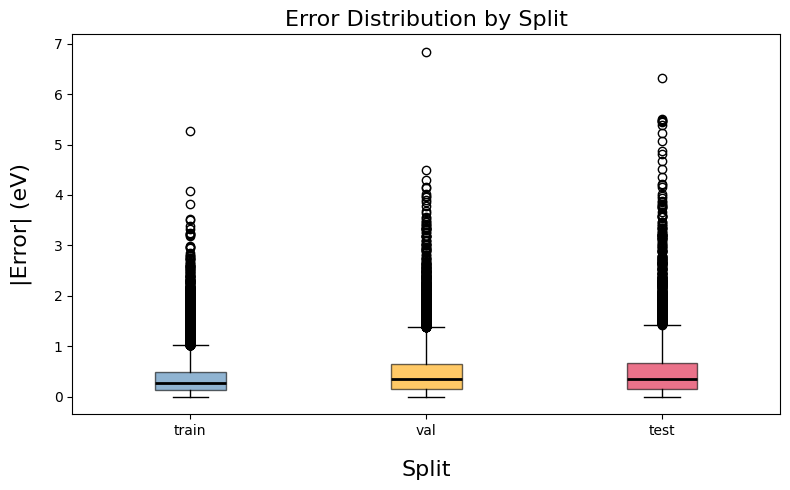

Saved: xai_error_split.png


In [9]:
# Split boxplot — one figure
if df_pred is not None and 'split' in df_pred.columns:
    plt.close('all')
    fig, ax = plt.subplots(figsize=(8, 5))
    split_order = [s for s in ['train','val','test'] if s in df_pred['split'].values]
    data_box    = [df_pred[df_pred['split']==s]['abs_error'].values for s in split_order]
    bp = ax.boxplot(data_box, labels=split_order, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], ['steelblue','orange','crimson']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_xlabel('Split', fontsize=16, labelpad=16)
    ax.set_ylabel('|Error| (eV)', fontsize=16, labelpad=16)
    ax.set_title('Error Distribution by Split', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_error_split.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print('Saved: xai_error_split.png')


In [10]:
# Worst N predictions table
if df_pred is not None:
    worst = df_pred.nlargest(N_WORST, 'abs_error')[['filename','cbm_true','cbm_pred','abs_error','signed_error']].reset_index(drop=True)
    print(f'Worst {N_WORST} predictions:')
    display(worst.style.background_gradient(subset=['abs_error'], cmap='Reds').format(
        {c:'{:.3f}' for c in ['cbm_true','cbm_pred','abs_error','signed_error']}))


Worst 30 predictions:


,filename,cbm_true,cbm_pred,abs_error,signed_error
0,mp-1014013,-2.567,4.276,6.842,6.842
1,mp-1023900,-1.959,4.358,6.316,6.316
2,mp-1203051,-2.145,3.365,5.510,5.510
3,mp-1213294,2.220,7.697,5.477,5.477
4,mp-990424,-1.914,3.554,5.467,5.467
5,mp-1211790,-0.063,5.403,5.465,5.465
6,mp-2646987,-1.250,4.192,5.443,5.443
7,mp-554134,-0.371,5.018,5.389,5.389
8,mp-1025888,-2.308,2.970,5.278,5.278
9,mp-1094080,-0.742,4.487,5.229,5.229


---
## ⚛️ Section 3 — Element Statistics

In [11]:
from tqdm.notebook import tqdm

def get_elements(filename):
    cif_name  = filename if filename.endswith('.cif') else filename + '.cif'
    cif_path  = CIF_DIR / cif_name
    if cif_path.exists():
        try:
            struct = Structure.from_file(str(cif_path))
            return list(set(str(s.specie.symbol) for s in struct))
        except: pass
    return []

if df_pred is not None:
    if 'split' in df_pred.columns:
        parts = []
        for split, grp in df_pred.groupby('split'):
            n = max(1, int(ELEM_SAMPLE_SIZE * len(grp) / len(df_pred)))
            parts.append(grp.sample(min(n, len(grp)), random_state=42))
        df_sample = pd.concat(parts).head(ELEM_SAMPLE_SIZE)
    else:
        df_sample = df_pred.sample(min(ELEM_SAMPLE_SIZE, len(df_pred)), random_state=42)

    print(f'Extracting element composition for {len(df_sample)} materials...')
    elem_records = []
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        for el in get_elements(row['filename']):
            elem_records.append({'filename':row['filename'],'element':el,
                                 'cbm_true':row['cbm_true'],'cbm_pred':row['cbm_pred'],
                                 'abs_error':row['abs_error'],'signed_error':row['signed_error']})
    df_elem = pd.DataFrame(elem_records)
    print(f'Records: {len(df_elem):,}  |  Unique elements: {df_elem["element"].nunique()}')
else:
    df_elem = None


Extracting element composition for 4999 materials...


  0%|          | 0/4999 [00:00<?, ?it/s]

Records: 19,031  |  Unique elements: 84


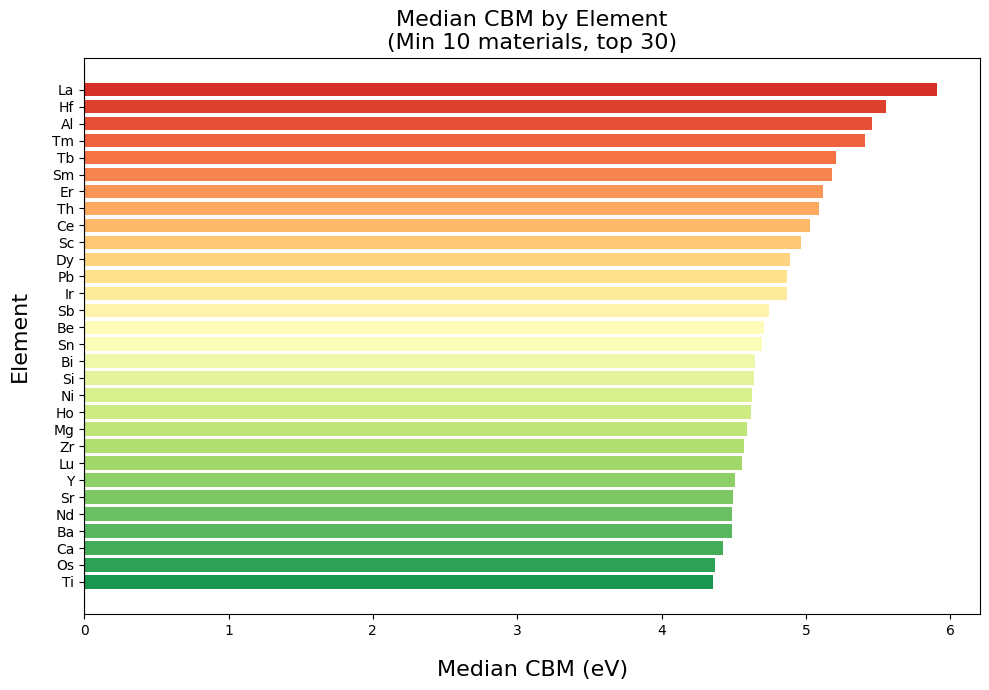

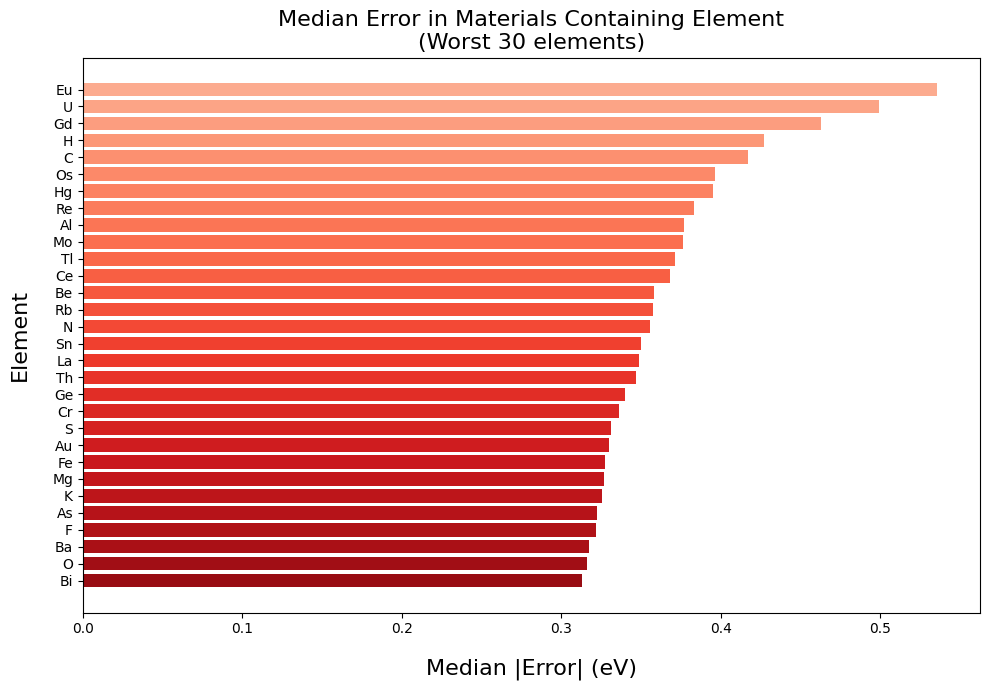

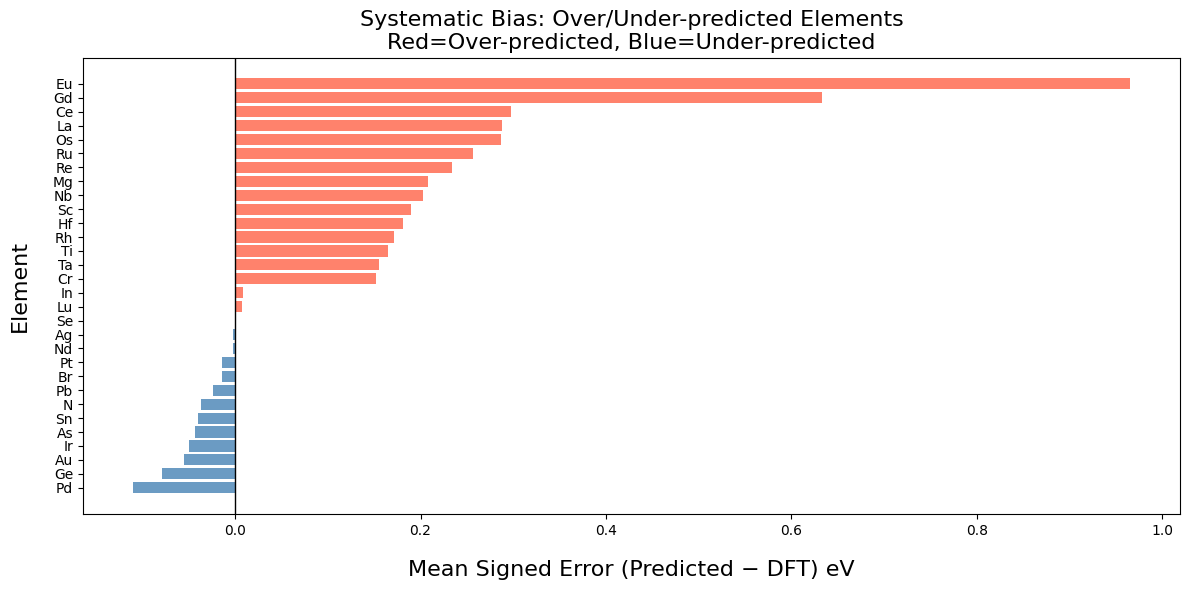

Saved: xai_element_cbm.png  xai_element_error.png  xai_element_bias.png


In [12]:
if df_elem is not None:
    elem_stats = df_elem.groupby('element').agg(
        n_materials=('filename','nunique'),
        median_cbm=('cbm_true','median'), mean_cbm=('cbm_true','mean'),
        median_abs_error=('abs_error','median'), mean_abs_error=('abs_error','mean'),
        mean_signed_error=('signed_error','mean')
    ).reset_index()
    elem_stats = elem_stats[elem_stats['n_materials'] >= 10]

    # Separate figures: Median CBM by element
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 7))
    top = elem_stats.sort_values('median_cbm', ascending=False).head(30)
    ax.barh(top['element'], top['median_cbm'],
            color=plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(top))))
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Median CBM (eV)', fontsize=16, labelpad=16)
    ax.set_ylabel('Element', fontsize=16, labelpad=16)
    ax.set_title('Median CBM by Element\n(Min 10 materials, top 30)', fontsize=16)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('xai_element_cbm.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Median error by element
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 7))
    err_sorted = elem_stats.sort_values('median_abs_error', ascending=False).head(30)
    ax.barh(err_sorted['element'], err_sorted['median_abs_error'],
            color=plt.cm.Reds(np.linspace(0.3, 0.9, len(err_sorted))))
    ax.set_xlabel('Median |Error| (eV)', fontsize=16, labelpad=16)
    ax.set_ylabel('Element', fontsize=16, labelpad=16)
    ax.set_title('Median Error in Materials Containing Element\n(Worst 30 elements)', fontsize=16)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('xai_element_error.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Systematic bias
    plt.close('all')
    fig, ax = plt.subplots(figsize=(12, 6))
    bias = elem_stats.sort_values('mean_signed_error')
    top_bias = pd.concat([bias.head(15), bias.tail(15)])
    colors_b = ['tomato' if v > 0 else 'steelblue' for v in top_bias['mean_signed_error']]
    ax.barh(top_bias['element'], top_bias['mean_signed_error'], color=colors_b, alpha=0.8)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Mean Signed Error (Predicted − DFT) eV', fontsize=16, labelpad=16)
    ax.set_ylabel('Element', fontsize=16, labelpad=16)
    ax.set_title('Systematic Bias: Over/Under-predicted Elements\nRed=Over-predicted, Blue=Under-predicted', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_element_bias.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_element_cbm.png  xai_element_error.png  xai_element_bias.png')


---
## 🔍 Section 2 — Integrated Gradients
> Which node feature (atomic_mass, X, etc.) matters most? Now reflects 7-feature input (embedding is separate branch).

In [13]:
from captum.attr import IntegratedGradients

def compute_ig(cif_path, model, tda_scaler, filename='', n_steps=50):
    data, symbols = cif_to_data(cif_path, tda_scaler, filename=filename)
    data = data.to(device)
    wrapper = CaptumWrapper(model, data).to(device)
    wrapper.eval()
    x = data.x.clone().requires_grad_(True)
    ig = IntegratedGradients(wrapper)
    attrs = ig.attribute(x, torch.zeros_like(x), n_steps=n_steps)
    return attrs.detach().cpu().numpy(), symbols

if df_pred is not None:
    sample_row = df_pred.nsmallest(50, 'abs_error').iloc[0]
    fname = sample_row['filename']
    sample_cif = CIF_DIR / (fname if fname.endswith('.cif') else fname+'.cif')
    print(f'Test material: {fname}')
    print(f'DFT CBM: {sample_row["cbm_true"]:.3f} eV  |  Predicted: {sample_row["cbm_pred"]:.3f} eV')
    attrs_single, symbols_single = compute_ig(sample_cif, model, tda_scaler, filename=fname)
    print(f'Attribution shape: {attrs_single.shape}')


Test material: mp-28673
DFT CBM: 3.899 eV  |  Predicted: 3.899 eV
Attribution shape: (44, 7)


Computing global feature importance (50 materials)...
Successful: 50


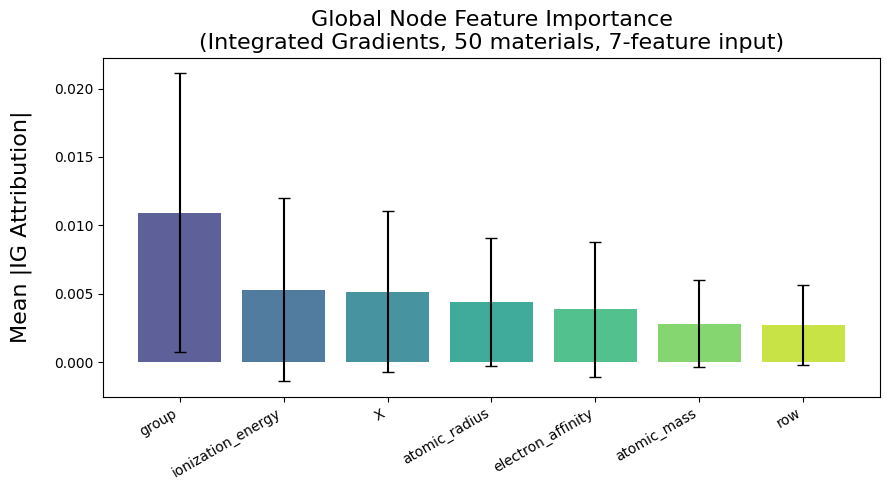

Saved: xai_feature_importance.png


In [14]:
# Global feature importance across 50 materials
print('Computing global feature importance (50 materials)...')
if df_pred is not None:
    pool = df_pred[df_pred['split']=='test'] if 'split' in df_pred.columns else df_pred
    sample_rows = pool.sample(min(50, len(pool)), random_state=42)
    all_attrs = []
    for _, row in sample_rows.iterrows():
        f = row['filename']
        cp = CIF_DIR / (f if f.endswith('.cif') else f+'.cif')
        if not cp.exists(): continue
        try:
            a, _ = compute_ig(cp, model, tda_scaler, filename=f, n_steps=25)
            all_attrs.append(np.abs(a).mean(axis=0))
        except: pass
    print(f'Successful: {len(all_attrs)}')

    if all_attrs:
        gi  = np.stack(all_attrs).mean(axis=0)
        gis = np.stack(all_attrs).std(axis=0)
        plt.close('all')
        fig, ax = plt.subplots(figsize=(9, 5))
        idx = np.argsort(gi)[::-1]
        ax.bar(range(len(FEAT_NAMES)),
               gi[idx], yerr=gis[idx],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(FEAT_NAMES))),
               capsize=4, alpha=0.85)
        ax.set_xticks(range(len(FEAT_NAMES)))
        ax.set_xticklabels([FEAT_NAMES[i] for i in idx], rotation=30, ha='right')
        ax.set_ylabel('Mean |IG Attribution|', fontsize=16, labelpad=16)
        ax.set_title('Global Node Feature Importance\n(Integrated Gradients, 50 materials, 7-feature input)', fontsize=16)
        plt.tight_layout()
        plt.savefig('xai_feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close('all')
        print('Saved: xai_feature_importance.png')


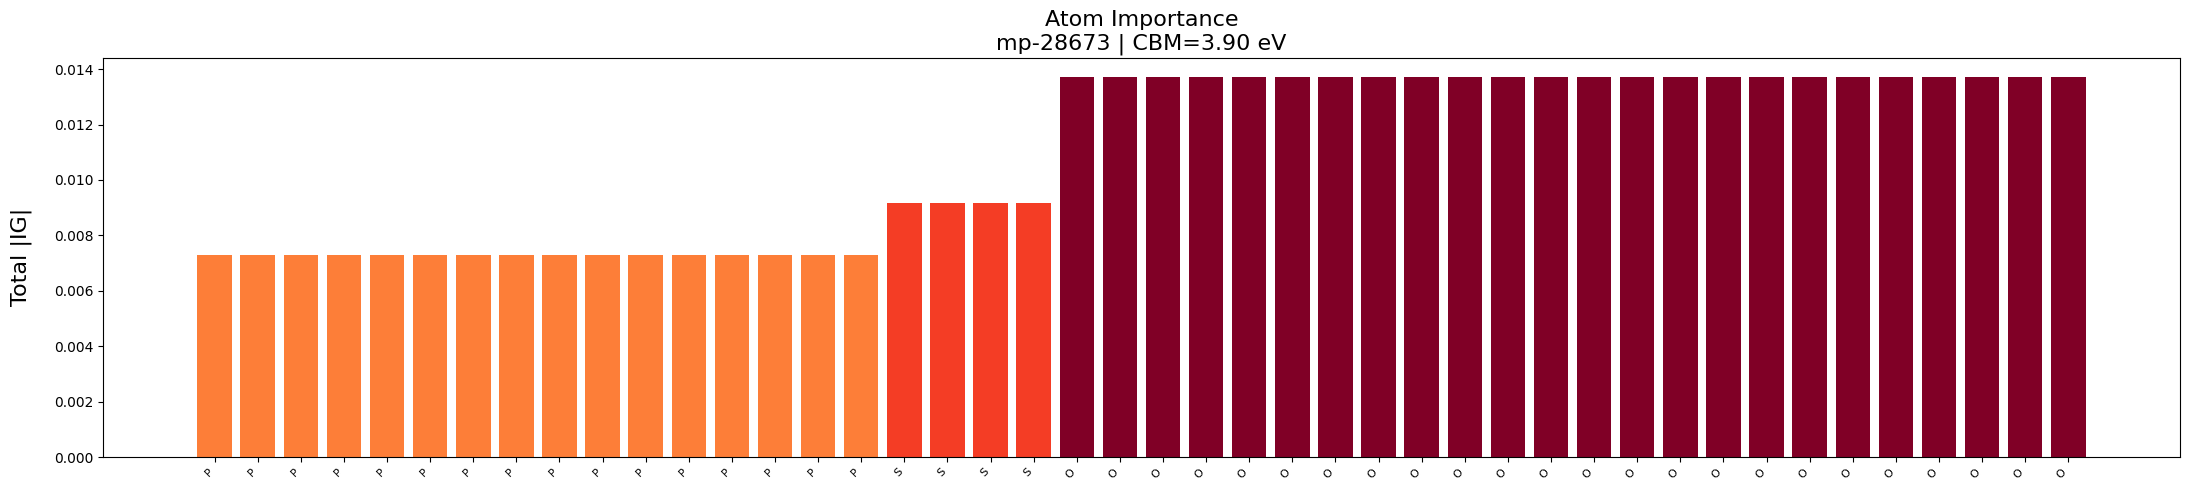

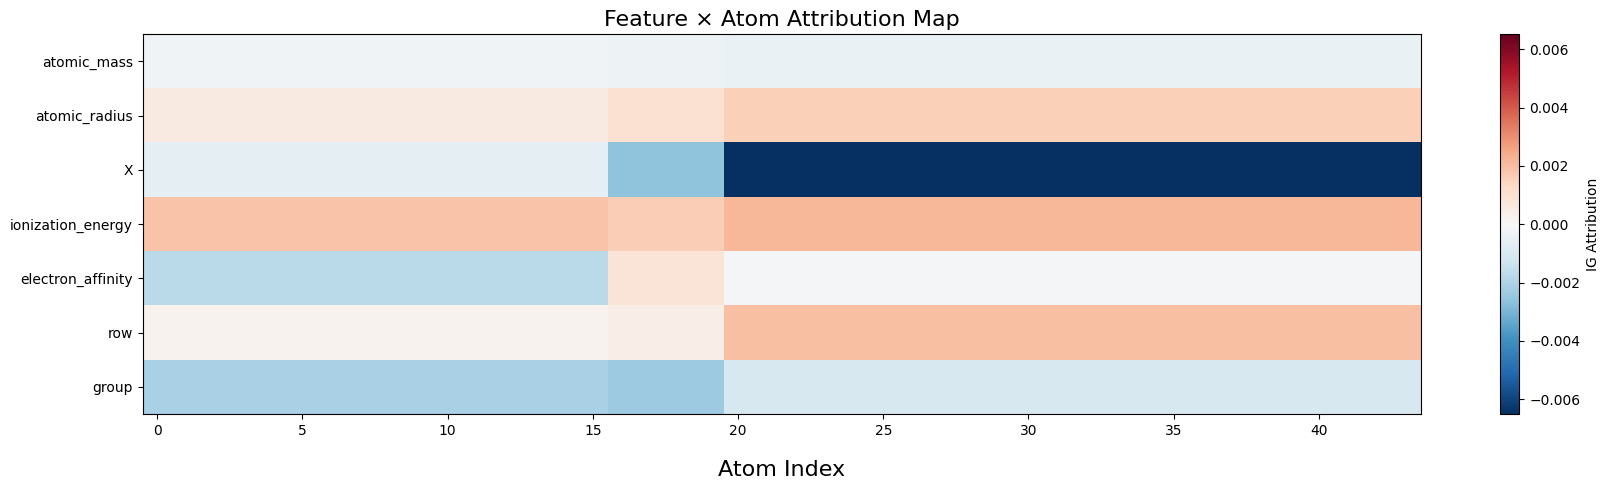

Saved: xai_atom_importance.png  xai_atom_ig_map.png


In [15]:
# Single material: per-atom IG map
if df_pred is not None and 'all_attrs' in dir() and len(all_attrs) > 0:
    attrs, symbols = compute_ig(sample_cif, model, tda_scaler, filename=fname)
    atom_imp = np.abs(attrs).sum(axis=1)

    # Per-atom bar
    plt.close('all')
    fig, ax = plt.subplots(figsize=(max(8, len(symbols)*0.5), 5))
    ax.bar(range(len(symbols)), atom_imp,
           color=plt.cm.YlOrRd(atom_imp / (atom_imp.max()+1e-9)))
    ax.set_xticks(range(len(symbols)))
    ax.set_xticklabels(symbols, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Total |IG|', fontsize=16, labelpad=16)
    ax.set_title(f'Atom Importance\n{fname} | CBM={sample_row["cbm_true"]:.2f} eV', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_atom_importance.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Feature x Atom heatmap
    plt.close('all')
    fig, ax = plt.subplots(figsize=(max(10, len(symbols)*0.4), 5))
    im = ax.imshow(attrs.T, aspect='auto', cmap='RdBu_r',
                   vmin=-np.abs(attrs).max(), vmax=np.abs(attrs).max())
    plt.colorbar(im, ax=ax, label='IG Attribution')
    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(FEAT_NAMES)
    ax.set_xlabel('Atom Index', fontsize=16, labelpad=16)
    ax.set_title('Feature × Atom Attribution Map', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_atom_ig_map.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_atom_importance.png  xai_atom_ig_map.png')


---
## 🕸️ Section 1 — GNNExplainer (Atom & Bond Importance)

In [16]:
def run_gnnexplainer(cif_path, model, tda_scaler, filename='', epochs=200):
    data, symbols = cif_to_data(cif_path, tda_scaler, filename=filename)
    wrapper = ModelWrapper(model, data.tda.clone(), data.megnet.clone()).to(device)
    wrapper.eval()
    explainer = Explainer(
        model=wrapper,
        algorithm=GNNExplainer(epochs=epochs),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(mode='regression', task_level='graph', return_type='raw'),
    )
    d = data.to(device)
    expl = explainer(x=d.x, edge_index=d.edge_index, edge_attr=d.edge_attr)
    return expl.node_mask.detach().cpu().numpy(), expl.edge_mask.detach().cpu().numpy(), symbols, data

print('GNNExplainer ready. Running on sample material...')
node_mask, edge_mask, symbols_gnn, data_gnn = run_gnnexplainer(
    sample_cif, model, tda_scaler, filename=fname)
print(f'node_mask: {node_mask.shape}  |  edge_mask: {edge_mask.shape}')


GNNExplainer ready. Running on sample material...
node_mask: (44, 7)  |  edge_mask: (528,)


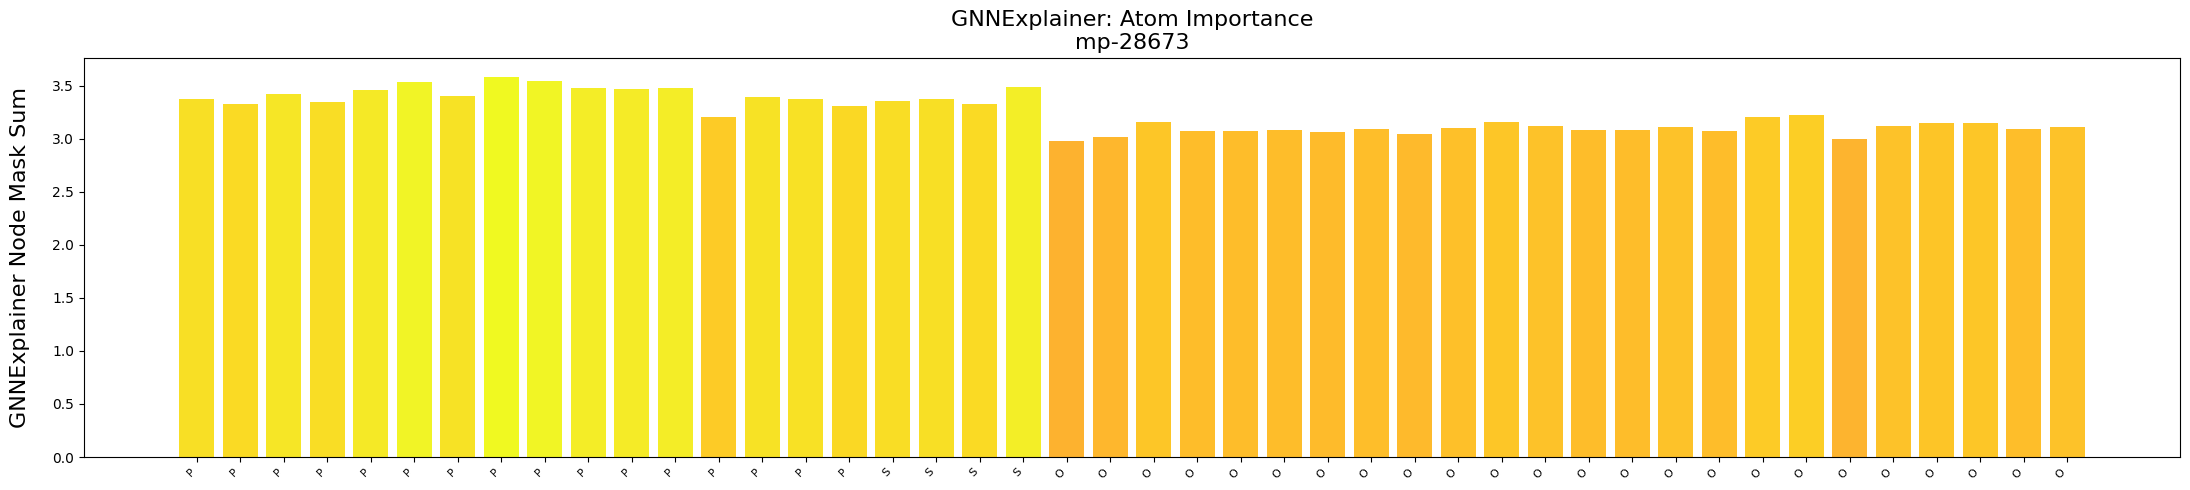

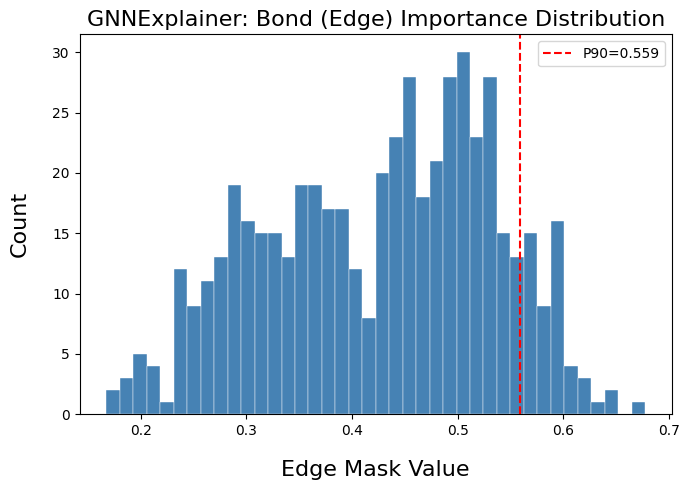

Saved: xai_gnnexplainer_atoms.png  xai_gnnexplainer_edges.png


In [17]:
atom_imp_gnn = node_mask.sum(axis=1)
norm_atom    = atom_imp_gnn / (atom_imp_gnn.max() + 1e-9)

# Atom importance bar
plt.close('all')
fig, ax = plt.subplots(figsize=(max(8, len(symbols_gnn)*0.5), 5))
ax.bar(range(len(symbols_gnn)), atom_imp_gnn,
       color=plt.cm.plasma(norm_atom))
ax.set_xticks(range(len(symbols_gnn)))
ax.set_xticklabels(symbols_gnn, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GNNExplainer Node Mask Sum', fontsize=16, labelpad=16)
ax.set_title(f'GNNExplainer: Atom Importance\n{fname}', fontsize=16)
plt.tight_layout()
plt.savefig('xai_gnnexplainer_atoms.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

# Edge mask histogram
plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(edge_mask, bins=40, color='steelblue', edgecolor='white', lw=0.3)
ax.axvline(np.percentile(edge_mask, 90), color='red', ls='--', lw=1.5,
           label=f'P90={np.percentile(edge_mask,90):.3f}')
ax.set_xlabel('Edge Mask Value', fontsize=16, labelpad=16)
ax.set_ylabel('Count', fontsize=16, labelpad=16)
ax.set_title('GNNExplainer: Bond (Edge) Importance Distribution', fontsize=16)
ax.legend()
plt.tight_layout()
plt.savefig('xai_gnnexplainer_edges.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print('Saved: xai_gnnexplainer_atoms.png  xai_gnnexplainer_edges.png')


In [18]:
# Crystal map (XY projection)
try:
    struct = Structure.from_file(str(sample_cif))
    coords = struct.cart_coords
    esrc   = data_gnn.edge_index[0].numpy()
    edst   = data_gnn.edge_index[1].numpy()
    thr    = np.percentile(edge_mask, 80)

    plt.close('all')
    fig, ax = plt.subplots(figsize=(9, 8))
    cmap_e = cm.get_cmap('hot_r')
    for i in range(len(esrc)):
        xl = [coords[esrc[i],0], coords[edst[i],0]]
        yl = [coords[esrc[i],1], coords[edst[i],1]]
        if edge_mask[i] >= thr:
            c = cmap_e((edge_mask[i]-thr)/(edge_mask.max()-thr+1e-9))
            ax.plot(xl, yl, color=c, lw=2.5, alpha=0.8)
        else:
            ax.plot(xl, yl, 'gray', lw=0.3, alpha=0.2)
    sc = ax.scatter(coords[:,0], coords[:,1], s=200*norm_atom+30,
                    c=atom_imp_gnn, cmap='plasma', zorder=5,
                    edgecolors='black', lw=0.5)
    plt.colorbar(sc, ax=ax, label='Atom Importance')
    for i, sym in enumerate(symbols_gnn):
        ax.annotate(sym, (coords[i,0], coords[i,1]), ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white', zorder=6)
    ax.set_xlabel('x (Å)', fontsize=16, labelpad=16)
    ax.set_ylabel('y (Å)', fontsize=16, labelpad=16)
    ax.set_title(f'GNNExplainer Crystal Map (XY Projection)\n{fname} | CBM={sample_row["cbm_true"]:.2f} eV', fontsize=16)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('xai_crystal_map.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_crystal_map.png')
except Exception as e:
    print(f'Crystal map failed: {e}')


Crystal map failed: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.


Bulk GNNExplainer (20 materials)...


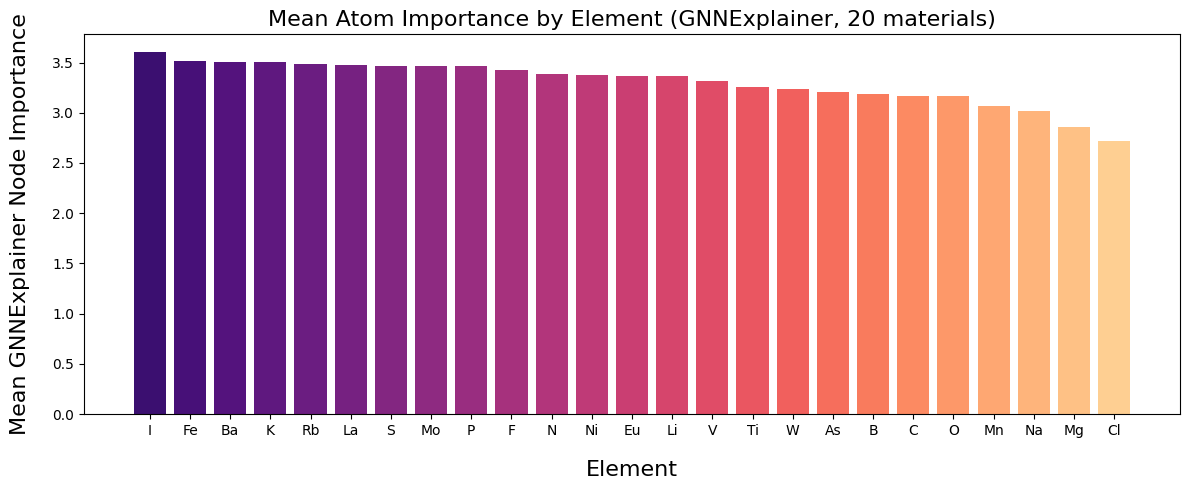

Saved: xai_gnnexplainer_elements.png


,element,mean_importance,n
13,I,3.600689,6
6,Fe,3.517023,7
17,Ba,3.504740,7
12,K,3.502736,16
0,Rb,3.490036,10
16,La,3.478623,3
8,S,3.469484,36
15,Mo,3.467000,8
2,P,3.465057,16
27,F,3.428715,12


In [19]:
# Bulk GNNExplainer — element-level average importance
print(f'Bulk GNNExplainer ({N_EXPLAIN} materials)...')
if df_pred is not None:
    pool2 = pool.sample(min(N_EXPLAIN, len(pool)), random_state=7)
    elem_gnn_imp = defaultdict(list)
    for _, row in pool2.iterrows():
        f  = row['filename']
        cp = CIF_DIR / (f if f.endswith('.cif') else f+'.cif')
        if not cp.exists(): continue
        try:
            nm, em, syms, _ = run_gnnexplainer(cp, model, tda_scaler, filename=f, epochs=100)
            for sym, imp in zip(syms, nm.sum(axis=1)):
                elem_gnn_imp[sym].append(imp)
        except: pass
    elem_imp_df = pd.DataFrame([
        {'element':el, 'mean_importance':np.mean(v), 'n':len(v)}
        for el, v in elem_gnn_imp.items() if len(v) >= 3
    ]).sort_values('mean_importance', ascending=False)

    plt.close('all')
    fig, ax = plt.subplots(figsize=(12, 5))
    top_e = elem_imp_df.head(25)
    ax.bar(top_e['element'], top_e['mean_importance'],
           color=plt.cm.magma(np.linspace(0.2, 0.9, len(top_e))))
    ax.set_xlabel('Element', fontsize=16, labelpad=16)
    ax.set_ylabel('Mean GNNExplainer Node Importance', fontsize=16, labelpad=16)
    ax.set_title(f'Mean Atom Importance by Element (GNNExplainer, {N_EXPLAIN} materials)', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_gnnexplainer_elements.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_gnnexplainer_elements.png')
    display(elem_imp_df.head(15))


---
## 🧬 Section 5 — MEGNet Embedding Branch Analysis
> **New section** — specific to the v4 three-branch architecture. Answers:
> - How much does each branch contribute to the final prediction?
> - Can we see structure in embedding space?
> - Which embedding dimensions are most predictive of CBM?

In [20]:
# 5a. Branch activation norms — how much does each branch 'fire'?
print('Computing branch activations (1000 materials)...')
if df_pred is not None:
    branch_sample = df_pred.sample(min(1000, len(df_pred)), random_state=42)
    branch_recs   = []
    model.eval()
    with torch.no_grad():
        for _, row in branch_sample.iterrows():
            f  = row['filename']
            cp = CIF_DIR / (f if f.endswith('.cif') else f+'.cif')
            if not cp.exists(): continue
            try:
                data, _ = cif_to_data(cp, tda_scaler, filename=f)
                b = Batch.from_data_list([data.to(device)])
                _, z, z_gnn, z_tda, z_meg = model.forward_branches(b)
                branch_recs.append({
                    'cbm_true':  row['cbm_true'],
                    'abs_error': row['abs_error'],
                    'norm_gnn':  float(z_gnn.norm().cpu()),
                    'norm_tda':  float(z_tda.norm().cpu()),
                    'norm_meg':  float(z_meg.norm().cpu()),
                    'emb_vec':   z_meg.squeeze(0).cpu().numpy(),
                })
            except: pass

    df_branch = pd.DataFrame([{k:v for k,v in r.items() if k!='emb_vec'} for r in branch_recs])
    emb_vecs  = np.array([r['emb_vec'] for r in branch_recs])  # (N, MEGNET_PROJ_DIM)
    cbm_vals  = df_branch['cbm_true'].values
    print(f'Branch activations computed: {len(df_branch)} materials')
    print(df_branch[['norm_gnn','norm_tda','norm_meg']].describe().round(3))


Computing branch activations (1000 materials)...
Branch activations computed: 1000 materials
       norm_gnn  norm_tda  norm_meg
count  1000.000  1000.000  1000.000
mean      6.369     5.517     2.899
std       2.700     0.000     0.524
min       2.675     5.517     1.749
25%       4.422     5.517     2.533
50%       5.628     5.517     2.818
75%       7.439     5.517     3.201
max      15.606     5.517     4.948


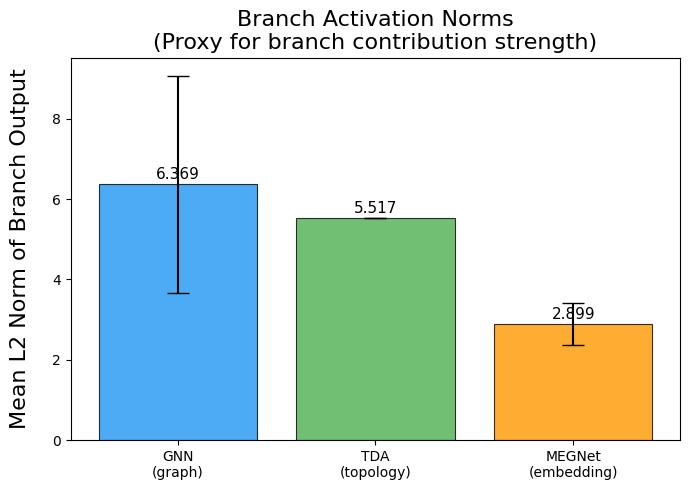

Saved: xai_branch_norms.png

Branch norms (mean ± std):
  GNN     : 6.3693 ± 2.6996
  TDA     : 5.5171 ± 0.0000
  MEGNet  : 2.8992 ± 0.5243


In [21]:
# Branch norm comparison — radar / bar
if 'df_branch' in dir() and len(df_branch) > 0:
    means = df_branch[['norm_gnn','norm_tda','norm_meg']].mean()
    stds  = df_branch[['norm_gnn','norm_tda','norm_meg']].std()
    labels= ['GNN\n(graph)', 'TDA\n(topology)', 'MEGNet\n(embedding)']
    colors_b = ['#2196F3','#4CAF50','#FF9800']

    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(labels, means.values, yerr=stds.values,
                  color=colors_b, alpha=0.8, capsize=8, edgecolor='black', lw=0.8)
    ax.set_ylabel('Mean L2 Norm of Branch Output', fontsize=16, labelpad=16)
    ax.set_title('Branch Activation Norms\n(Proxy for branch contribution strength)', fontsize=16)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.savefig('xai_branch_norms.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_branch_norms.png')
    print(f'\nBranch norms (mean ± std):')
    for name, m, s in zip(['GNN','TDA','MEGNet'], means.values, stds.values):
        print(f'  {name:8s}: {m:.4f} ± {s:.4f}')


UMAP of MEGNet projected embeddings...


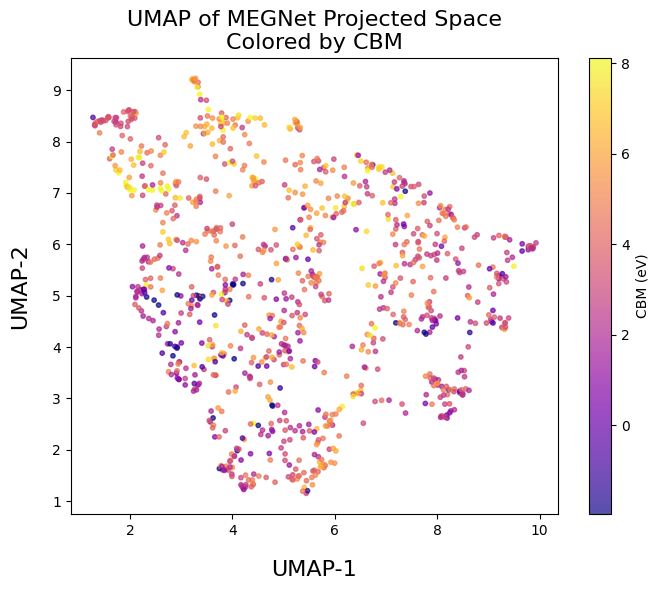

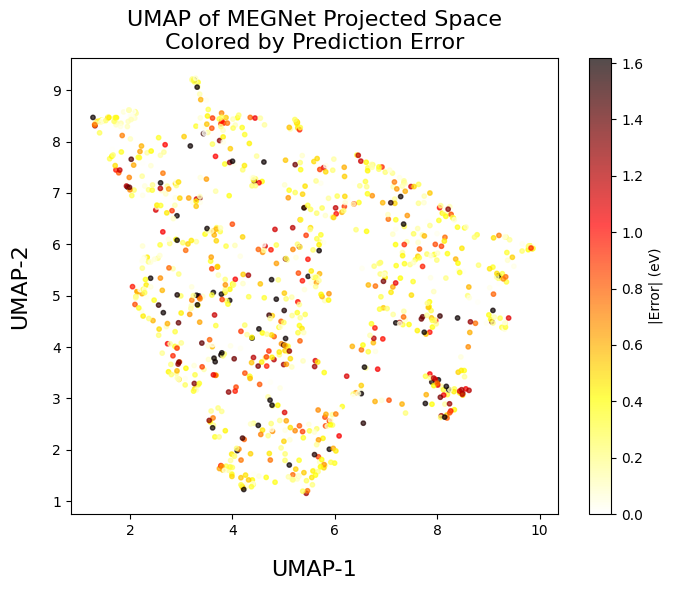

Saved: xai_emb_umap_cbm.png  xai_emb_umap_error.png


In [22]:
# 5b. MEGNet projected space UMAP — colored by CBM and by error
print('UMAP of MEGNet projected embeddings...')
if 'emb_vecs' in dir() and len(emb_vecs) > 20:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=20, min_dist=0.1)
    E2 = reducer.fit_transform(emb_vecs)

    # Colored by CBM
    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(E2[:,0], E2[:,1], c=cbm_vals, cmap='plasma', s=10, alpha=0.7,
                    vmin=np.percentile(cbm_vals,2), vmax=np.percentile(cbm_vals,98))
    plt.colorbar(sc, ax=ax, label='CBM (eV)')
    ax.set_xlabel('UMAP-1', fontsize=16, labelpad=16)
    ax.set_ylabel('UMAP-2', fontsize=16, labelpad=16)
    ax.set_title('UMAP of MEGNet Projected Space\nColored by CBM', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_emb_umap_cbm.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Colored by error
    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 6))
    sc2 = ax.scatter(E2[:,0], E2[:,1], c=df_branch['abs_error'].values,
                     cmap='hot_r', s=10, alpha=0.7,
                     vmin=0, vmax=np.percentile(df_branch['abs_error'],95))
    plt.colorbar(sc2, ax=ax, label='|Error| (eV)')
    ax.set_xlabel('UMAP-1', fontsize=16, labelpad=16)
    ax.set_ylabel('UMAP-2', fontsize=16, labelpad=16)
    ax.set_title('UMAP of MEGNet Projected Space\nColored by Prediction Error', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_emb_umap_error.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_emb_umap_cbm.png  xai_emb_umap_error.png')


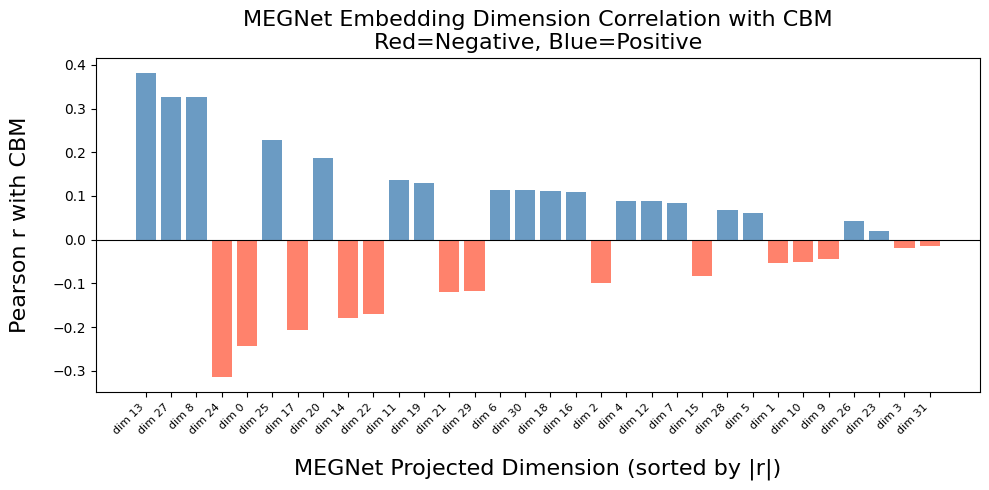

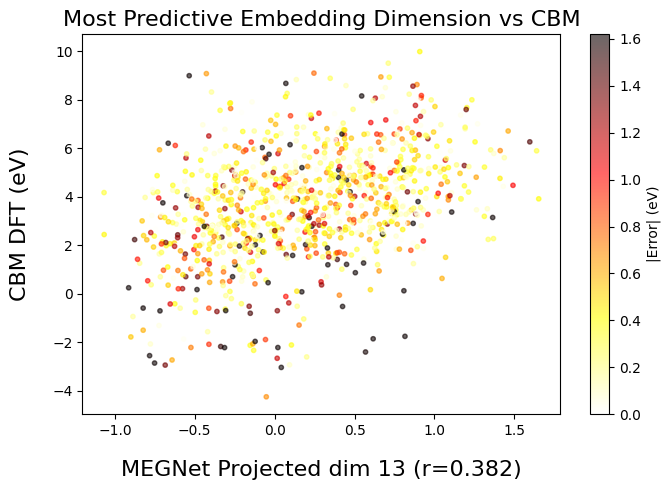

Saved: xai_emb_dim_corr.png  xai_emb_top_dim.png


In [23]:
# 5c. Per-dimension correlation: which emb dim predicts CBM best?
if 'emb_vecs' in dir() and len(emb_vecs) > 20:
    dim_corrs = [np.corrcoef(emb_vecs[:,d], cbm_vals)[0,1]
                 for d in range(emb_vecs.shape[1])]
    dim_corrs = np.array(dim_corrs)
    sorted_idx = np.argsort(np.abs(dim_corrs))[::-1]

    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_dim = ['tomato' if c < 0 else 'steelblue' for c in dim_corrs[sorted_idx]]
    ax.bar(range(len(dim_corrs)), dim_corrs[sorted_idx], color=colors_dim, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(dim_corrs)))
    ax.set_xticklabels([f'dim {sorted_idx[i]}' for i in range(len(dim_corrs))],
                       rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('MEGNet Projected Dimension (sorted by |r|)', fontsize=16, labelpad=16)
    ax.set_ylabel('Pearson r with CBM', fontsize=16, labelpad=16)
    ax.set_title('MEGNet Embedding Dimension Correlation with CBM\nRed=Negative, Blue=Positive', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_emb_dim_corr.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Scatter: most correlated dim vs CBM
    top_dim = sorted_idx[0]
    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(emb_vecs[:,top_dim], cbm_vals,
                    c=df_branch['abs_error'].values, cmap='hot_r',
                    s=10, alpha=0.6, vmin=0,
                    vmax=np.percentile(df_branch['abs_error'],95))
    plt.colorbar(sc, ax=ax, label='|Error| (eV)')
    ax.set_xlabel(f'MEGNet Projected dim {top_dim} (r={dim_corrs[top_dim]:.3f})', fontsize=16, labelpad=16)
    ax.set_ylabel('CBM DFT (eV)', fontsize=16, labelpad=16)
    ax.set_title(f'Most Predictive Embedding Dimension vs CBM', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_emb_top_dim.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_emb_dim_corr.png  xai_emb_top_dim.png')


In [24]:
# 5d. Branch ablation: GNN only vs GNN+TDA vs GNN+TDA+MEGNet (using predictions)
# Requires separate runs — show from predictions CSV if split column exists
# If you have predictions from baseline (no emb) model saved separately, load here:
BASELINE_PRED_CSV = 'predictions_no_emb.csv'  # optional

if df_pred is not None and Path(BASELINE_PRED_CSV).exists():
    df_base = pd.read_csv(BASELINE_PRED_CSV)
    df_base['abs_error'] = np.abs(df_base['cbm_pred'] - df_base['cbm_true'])

    plt.close('all')
    fig, ax = plt.subplots(figsize=(8, 5))
    labels_abl = ['Without MEGNet Emb', 'With MEGNet Emb (v4)']
    maes_abl   = [mean_absolute_error(df_base['cbm_true'], df_base['cbm_pred']),
                  mean_absolute_error(df_pred['cbm_true'], df_pred['cbm_pred'])]
    bars_abl = ax.bar(labels_abl, maes_abl, color=['#90CAF9','#1565C0'], alpha=0.85,
                      edgecolor='black', lw=0.8)
    for bar, val in zip(bars_abl, maes_abl):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.4f} eV', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_ylabel('Val MAE (eV)', fontsize=16, labelpad=16)
    ax.set_title('Branch Ablation: MEGNet Embedding Impact', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_branch_ablation.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_branch_ablation.png')
    delta = maes_abl[0] - maes_abl[1]
    print(f'MAE improvement from MEGNet branch: {delta:+.4f} eV ({delta/maes_abl[0]*100:+.1f}%)')
else:
    print(f'{BASELINE_PRED_CSV} not found — run without --emb_csv to generate baseline predictions')


predictions_no_emb.csv not found — run without --emb_csv to generate baseline predictions


---
## 🔬 Section 6 — Literature-Inspired Visualizations
Sources: CGCNN (2018), MEGNet (2019), S-CGCNN (2024), ACGNet (2023), Masuda & Tanabe (2024), GeoCGNN (2021)

In [25]:
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,'-m','pip','install','umap-learn','-q'])
    import umap
print('umap-learn ready.')


umap-learn ready.


### Visual 1 — 2D Density Histogram (CGCNN style)

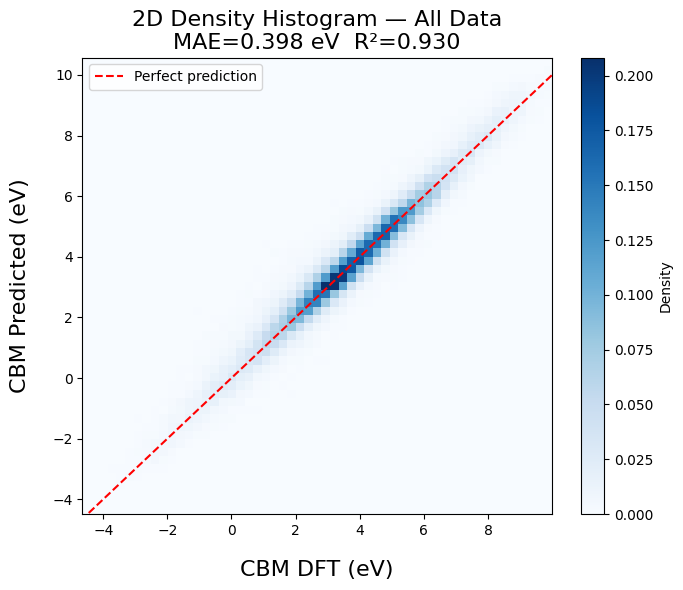

Saved: xai_2d_hist_all.png


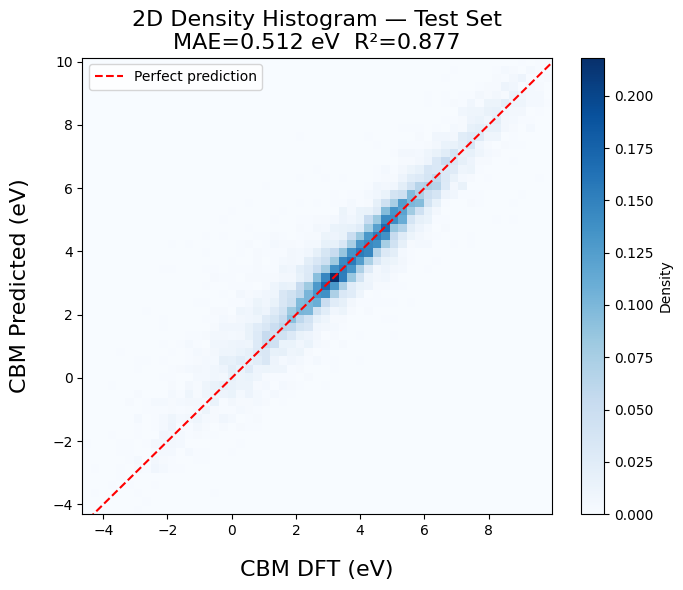

Saved: xai_2d_hist_test.png


In [26]:
if df_pred is not None:
    for label, subset, fname_out in [
        ('All Data', df_pred, 'xai_2d_hist_all.png'),
        ('Test Set', df_pred[df_pred['split']=='test'] if 'split' in df_pred.columns else df_pred, 'xai_2d_hist_test.png'),
    ]:
        if len(subset) < 10: continue
        m_s = mean_absolute_error(subset['cbm_true'], subset['cbm_pred'])
        r_s = r2_score(subset['cbm_true'], subset['cbm_pred'])
        plt.close('all')
        fig, ax = plt.subplots(figsize=(7, 6))
        h = ax.hist2d(subset['cbm_true'], subset['cbm_pred'],
                      bins=55, cmap='Blues', density=True)
        plt.colorbar(h[3], ax=ax, label='Density')
        lim = [subset['cbm_true'].min()-0.3, subset['cbm_true'].max()+0.3]
        ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
        ax.set_xlabel('CBM DFT (eV)', fontsize=16, labelpad=16)
        ax.set_ylabel('CBM Predicted (eV)', fontsize=16, labelpad=16)
        ax.set_title(f'2D Density Histogram — {label}\nMAE={m_s:.3f} eV  R²={r_s:.3f}', fontsize=16)
        ax.legend()
        plt.tight_layout()
        plt.savefig(fname_out, dpi=150, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f'Saved: {fname_out}')


### Visual 2 — Full Latent Space UMAP (all three branches fused)

Vectors: 3000  shape: (3000, 224)


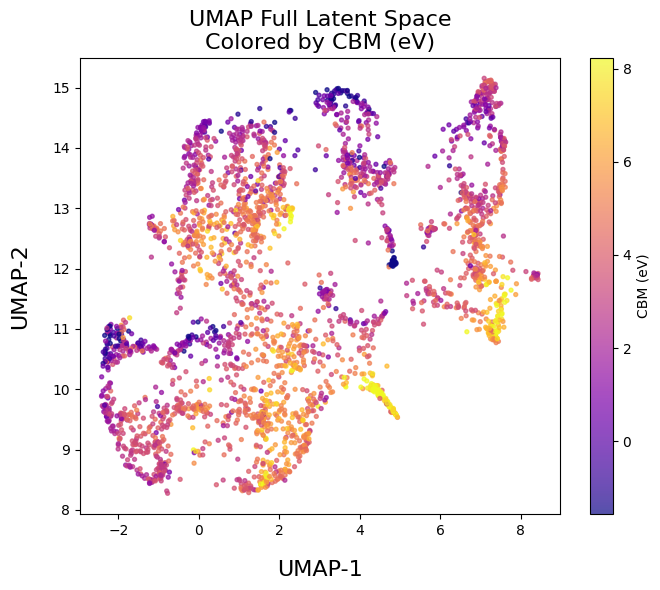

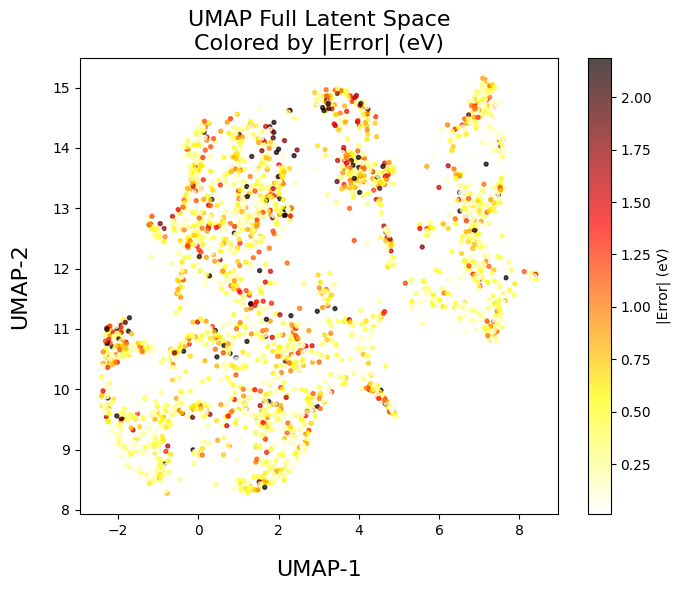

Saved: xai_umap_full_cbm.png  xai_umap_full_error.png


In [27]:
print('Collecting full latent vectors (max 3000)...')
if df_pred is not None:
    umap_sample = df_pred.sample(min(3000, len(df_pred)), random_state=42)
    lat_vecs, lat_cbm = [], []
    model.eval()
    with torch.no_grad():
        for _, row in umap_sample.iterrows():
            f  = row['filename']
            cp = CIF_DIR / (f if f.endswith('.cif') else f+'.cif')
            if not cp.exists(): continue
            try:
                data, _ = cif_to_data(cp, tda_scaler, filename=f)
                _, z = model(Batch.from_data_list([data.to(device)]))
                lat_vecs.append(z.squeeze(0).cpu().numpy())
                lat_cbm.append(row['cbm_true'])
            except: pass
    Z = np.array(lat_vecs); C = np.array(lat_cbm)
    print(f'Vectors: {len(Z)}  shape: {Z.shape}')
    reducer2 = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    Z2 = reducer2.fit_transform(Z)

    for color_arr, cmap, cbar_label, fname_out in [
        (C, 'plasma', 'CBM (eV)', 'xai_umap_full_cbm.png'),
        (umap_sample['abs_error'].values[:len(Z)], 'hot_r', '|Error| (eV)', 'xai_umap_full_error.png'),
    ]:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(7, 6))
        sc = ax.scatter(Z2[:,0], Z2[:,1], c=color_arr, cmap=cmap, s=8, alpha=0.7,
                        vmin=np.percentile(color_arr,2), vmax=np.percentile(color_arr,98))
        plt.colorbar(sc, ax=ax, label=cbar_label)
        ax.set_xlabel('UMAP-1', fontsize=16, labelpad=16)
        ax.set_ylabel('UMAP-2', fontsize=16, labelpad=16)
        ax.set_title(f'UMAP Full Latent Space\nColored by {cbar_label}', fontsize=16)
        plt.tight_layout()
        plt.savefig(fname_out, dpi=150, bbox_inches='tight'); plt.show(); plt.close('all')
    print('Saved: xai_umap_full_cbm.png  xai_umap_full_error.png')


### Visual 3 — Periodic Table Heatmaps

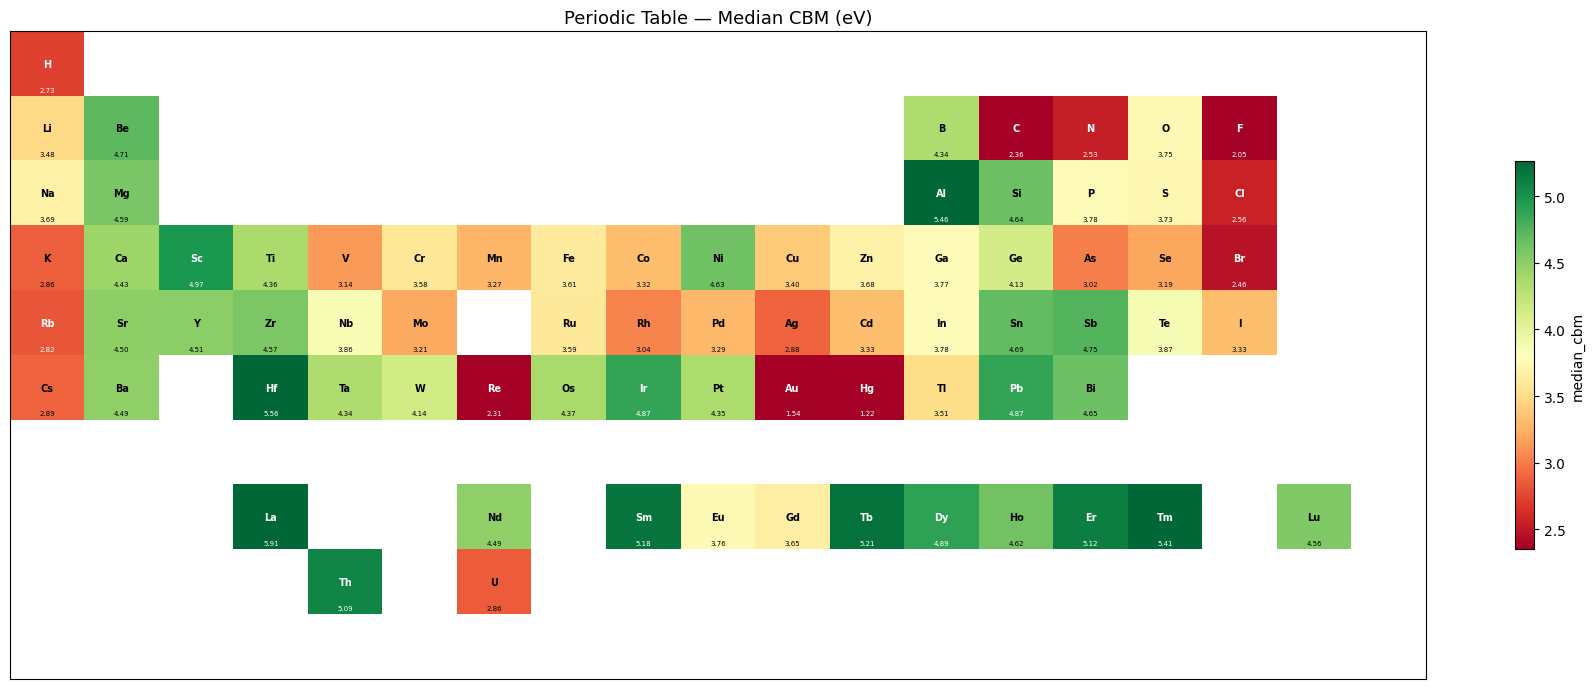

Saved: xai_periodic_cbm.png


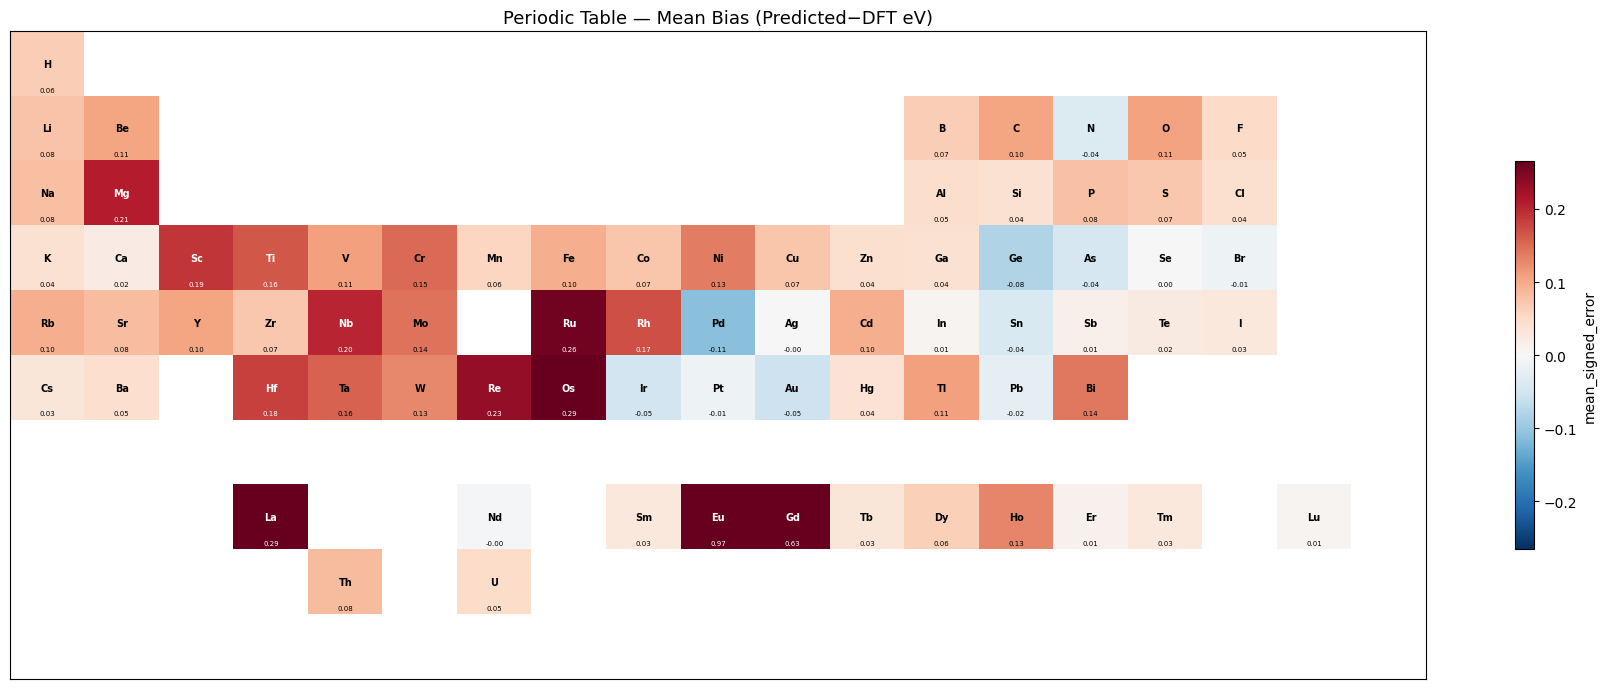

Saved: xai_periodic_bias.png


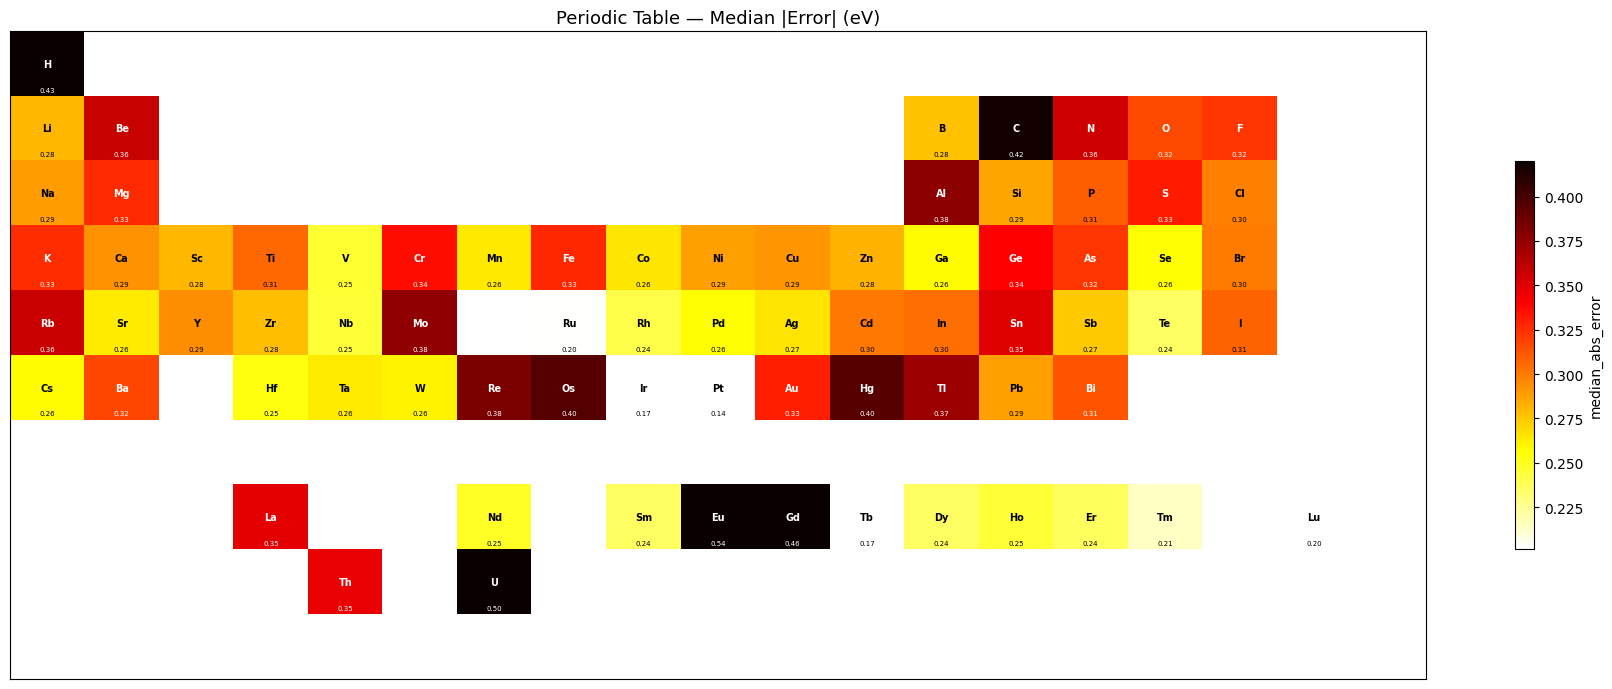

Saved: xai_periodic_error.png


In [28]:
PERIODIC_POS = {
    'H':(1,1),'He':(1,18),'Li':(2,1),'Be':(2,2),'B':(2,13),'C':(2,14),'N':(2,15),
    'O':(2,16),'F':(2,17),'Ne':(2,18),'Na':(3,1),'Mg':(3,2),'Al':(3,13),'Si':(3,14),
    'P':(3,15),'S':(3,16),'Cl':(3,17),'Ar':(3,18),'K':(4,1),'Ca':(4,2),'Sc':(4,3),
    'Ti':(4,4),'V':(4,5),'Cr':(4,6),'Mn':(4,7),'Fe':(4,8),'Co':(4,9),'Ni':(4,10),
    'Cu':(4,11),'Zn':(4,12),'Ga':(4,13),'Ge':(4,14),'As':(4,15),'Se':(4,16),
    'Br':(4,17),'Kr':(4,18),'Rb':(5,1),'Sr':(5,2),'Y':(5,3),'Zr':(5,4),'Nb':(5,5),
    'Mo':(5,6),'Tc':(5,7),'Ru':(5,8),'Rh':(5,9),'Pd':(5,10),'Ag':(5,11),'Cd':(5,12),
    'In':(5,13),'Sn':(5,14),'Sb':(5,15),'Te':(5,16),'I':(5,17),'Xe':(5,18),
    'Cs':(6,1),'Ba':(6,2),'La':(8,4),'Hf':(6,4),'Ta':(6,5),'W':(6,6),'Re':(6,7),
    'Os':(6,8),'Ir':(6,9),'Pt':(6,10),'Au':(6,11),'Hg':(6,12),'Tl':(6,13),'Pb':(6,14),
    'Bi':(6,15),'Po':(6,16),'Nd':(8,7),'Sm':(8,9),'Eu':(8,10),'Gd':(8,11),'Tb':(8,12),
    'Dy':(8,13),'Ho':(8,14),'Er':(8,15),'Tm':(8,16),'Yb':(8,17),'Lu':(8,18),
    'Th':(9,5),'U':(9,7),
}

def plot_periodic_heatmap(elem_stats_df, value_col, title, cmap, fname_out, center=None):
    val_dict = dict(zip(elem_stats_df['element'], elem_stats_df[value_col]))
    grid = np.full((10, 19), np.nan)
    for el, (row, col) in PERIODIC_POS.items():
        if el in val_dict: grid[row-1, col-1] = val_dict[el]
    vmin = np.nanpercentile(grid, 5); vmax = np.nanpercentile(grid, 95)
    if center is not None:
        v = max(abs(vmin-center), abs(vmax-center))
        vmin, vmax = center-v, center+v
    plt.close('all')
    fig, ax = plt.subplots(figsize=(18, 7))
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label=value_col, shrink=0.6)
    for el, (row, col) in PERIODIC_POS.items():
        if el in val_dict:
            v = val_dict[el]
            lum = sum(x*w for x,w in zip(im.cmap(im.norm(v))[:3], [0.299,0.587,0.114]))
            tc = 'white' if lum < 0.5 else 'black'
            ax.text(col-1, row-1, el,          ha='center', va='center', fontsize=7, fontweight='bold', color=tc)
            ax.text(col-1, row-0.6, f'{v:.2f}', ha='center', va='center', fontsize=5, color=tc)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname_out, dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'Saved: {fname_out}')

if 'elem_stats' in dir():
    plot_periodic_heatmap(elem_stats, 'median_cbm',        'Periodic Table — Median CBM (eV)',                  'RdYlGn',  'xai_periodic_cbm.png')
    plot_periodic_heatmap(elem_stats, 'mean_signed_error', 'Periodic Table — Mean Bias (Predicted−DFT eV)',      'RdBu_r',  'xai_periodic_bias.png', center=0.0)
    plot_periodic_heatmap(elem_stats, 'median_abs_error',  'Periodic Table — Median |Error| (eV)',               'hot_r',   'xai_periodic_error.png')
else:
    print('Run Section 3 first.')


### Visual 4 — Crystal System Analysis

Extracting crystal systems (1000 materials)...
Systems found: {'monoclinic': 328, 'triclinic': 212, 'orthorhombic': 202, 'tetragonal': 89, 'cubic': 84, 'trigonal': 56, 'hexagonal': 29}


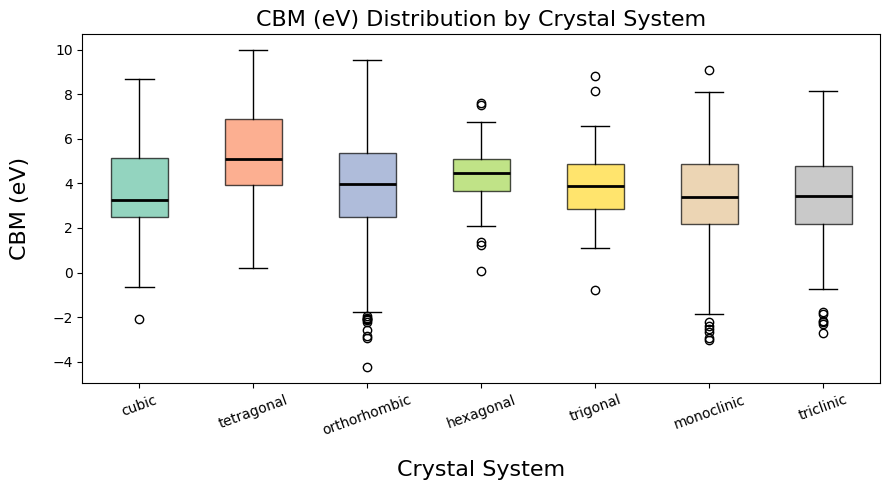

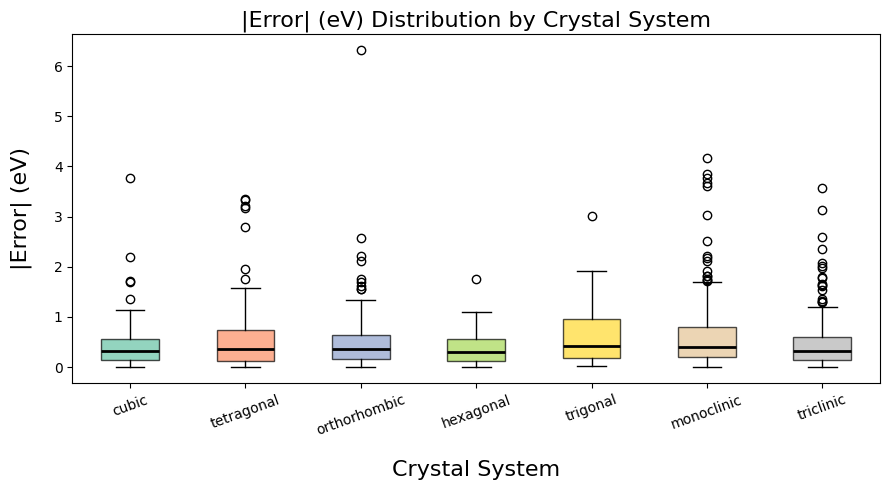

Saved: xai_crystal_cbm.png  xai_crystal_error.png


In [29]:
def get_crystal_system(filename):
    cp = CIF_DIR / (filename if filename.endswith('.cif') else filename+'.cif')
    if not cp.exists(): return None, None
    try:
        from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
        sga = SpacegroupAnalyzer(Structure.from_file(str(cp)), symprec=0.1)
        return sga.get_crystal_system(), sga.get_space_group_number()
    except: return None, None

if df_pred is not None:
    print('Extracting crystal systems (1000 materials)...')
    sym_sample  = df_pred.sample(min(1000, len(df_pred)), random_state=42)
    sym_records = []
    for _, row in sym_sample.iterrows():
        cs, sg = get_crystal_system(row['filename'])
        if cs: sym_records.append({'crystal_system':cs,'cbm_true':row['cbm_true'],'abs_error':row['abs_error']})
    df_sym = pd.DataFrame(sym_records)
    print(f'Systems found: {df_sym["crystal_system"].value_counts().to_dict()}')

    if len(df_sym) > 10:
        order = [s for s in ['cubic','tetragonal','orthorhombic','hexagonal','trigonal','monoclinic','triclinic']
                 if s in df_sym['crystal_system'].values]
        palette = plt.cm.Set2(np.linspace(0,1,len(order)))
        for yval, ylabel, fname_out in [
            ('cbm_true', 'CBM (eV)', 'xai_crystal_cbm.png'),
            ('abs_error','|Error| (eV)', 'xai_crystal_error.png'),
        ]:
            plt.close('all')
            fig, ax = plt.subplots(figsize=(9, 5))
            bp = ax.boxplot([df_sym[df_sym['crystal_system']==s][yval].values for s in order],
                            labels=order, patch_artist=True,
                            medianprops=dict(color='black', lw=2))
            for patch, color in zip(bp['boxes'], palette):
                patch.set_facecolor(color); patch.set_alpha(0.7)
            ax.set_xlabel('Crystal System', fontsize=16, labelpad=16)
            ax.set_ylabel(ylabel, fontsize=16, labelpad=16)
            ax.set_title(f'{ylabel} Distribution by Crystal System', fontsize=16)
            ax.tick_params(axis='x', rotation=20)
            plt.tight_layout()
            plt.savefig(fname_out, dpi=150, bbox_inches='tight')
            plt.show(); plt.close('all')
        print('Saved: xai_crystal_cbm.png  xai_crystal_error.png')


### Visual 5 — Structural Features vs CBM

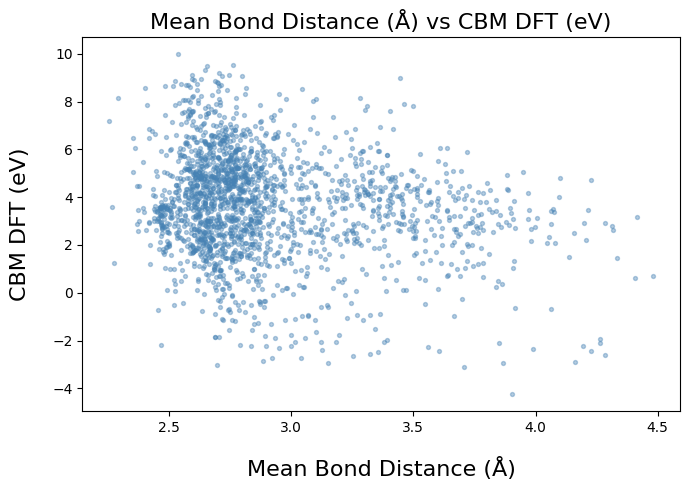

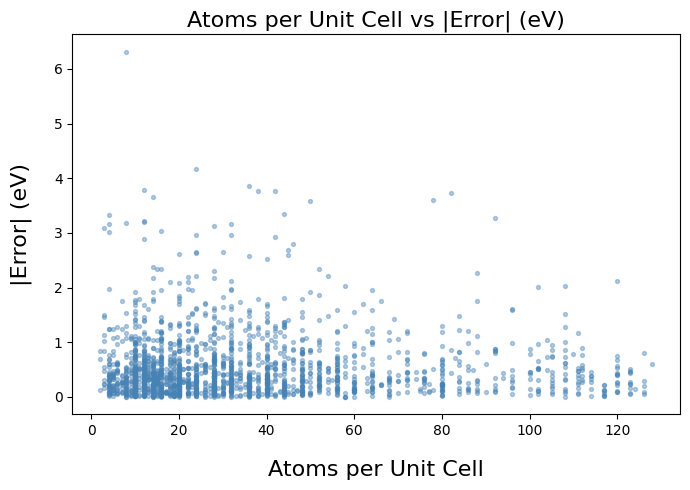

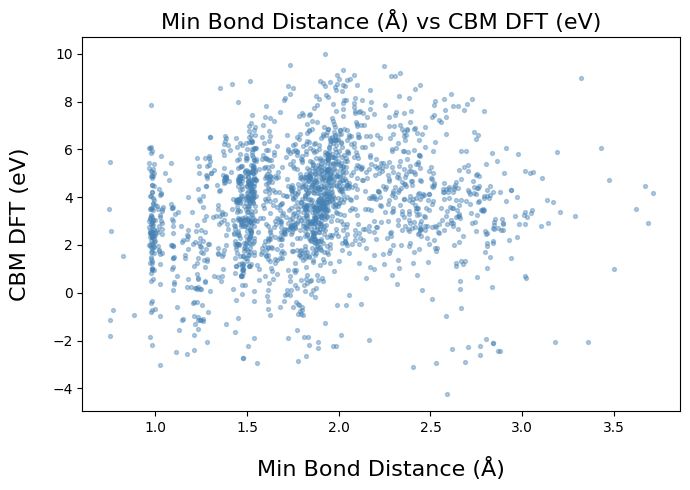

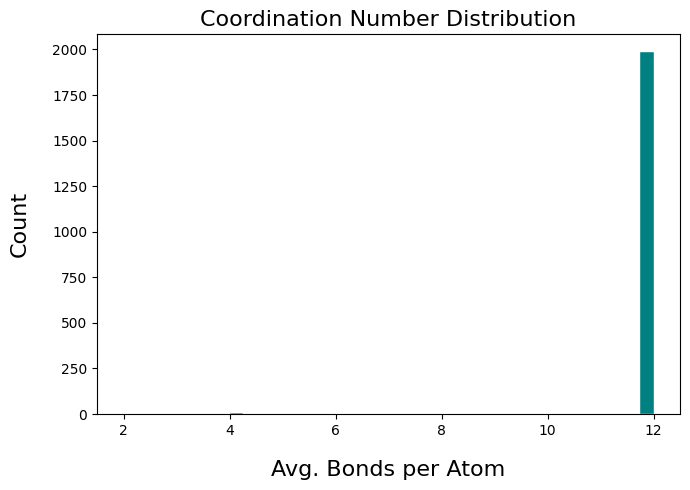

Saved: structural feature plots


In [30]:
if df_pred is not None:
    dist_sample = df_pred.sample(min(2000, len(df_pred)), random_state=42)
    dist_recs   = []
    for _, row in dist_sample.iterrows():
        stem  = row['filename'].replace('.cif','')
        cpath = CACHE_DIR / (stem+'.pt')
        if not cpath.exists(): continue
        try:
            d = torch.load(cpath, weights_only=False)
            # v2: edge_attr (E, 16) RBF — peak RBF dim ile yaklaşık mesafe yeniden hesapla
            # argmax → hangi RBF merkezinde pik → mesafe tahmini
            ea = d.edge_attr  # (E, 16)
            peak_idx = ea.argmax(dim=1).float()  # [0,15]
            dists = (peak_idx / (RBF_COUNT - 1)) * CUTOFF_RADIUS  # [0, CUTOFF_RADIUS]
            dist_recs.append({
                'mean_dist': dists.mean().item(), 'min_dist': dists.min().item(),
                'n_atoms': d.x.shape[0],
                'n_edges': len(dists),
                'cbm_true': row['cbm_true'], 'abs_error': row['abs_error']
            })
        except: pass
    df_dist = pd.DataFrame(dist_recs)

    plots = [
        ('mean_dist', 'cbm_true',  'Mean Bond Distance (Å)',    'CBM DFT (eV)',    'xai_dist_vs_cbm.png'),
        ('n_atoms',   'abs_error', 'Atoms per Unit Cell',       '|Error| (eV)',    'xai_natoms_vs_error.png'),
        ('min_dist',  'cbm_true',  'Min Bond Distance (Å)',     'CBM DFT (eV)',    'xai_mindist_vs_cbm.png'),
    ]
    for xcol, ycol, xlbl, ylbl, fname_out in plots:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(df_dist[xcol], df_dist[ycol], s=8, alpha=0.4, c='steelblue')
        ax.set_xlabel(xlbl, fontsize=16, labelpad=16)
        ax.set_ylabel(ylbl, fontsize=16, labelpad=16)
        ax.set_title(f'{xlbl} vs {ylbl}', fontsize=16)
        plt.tight_layout()
        plt.savefig(fname_out, dpi=150, bbox_inches='tight')
        plt.show(); plt.close('all')

    # Coordination number histogram
    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(df_dist['n_edges']/df_dist['n_atoms'], bins=40,
            color='teal', edgecolor='white', lw=0.3)
    ax.set_xlabel('Avg. Bonds per Atom', fontsize=16, labelpad=16)
    ax.set_ylabel('Count', fontsize=16, labelpad=16)
    ax.set_title('Coordination Number Distribution', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_coordination.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: structural feature plots')


### Visual 6 — KDE Distribution: DFT vs Predicted

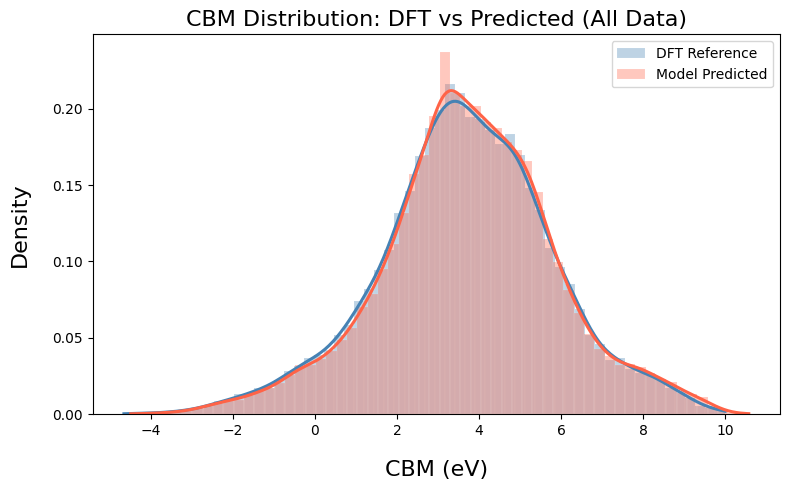

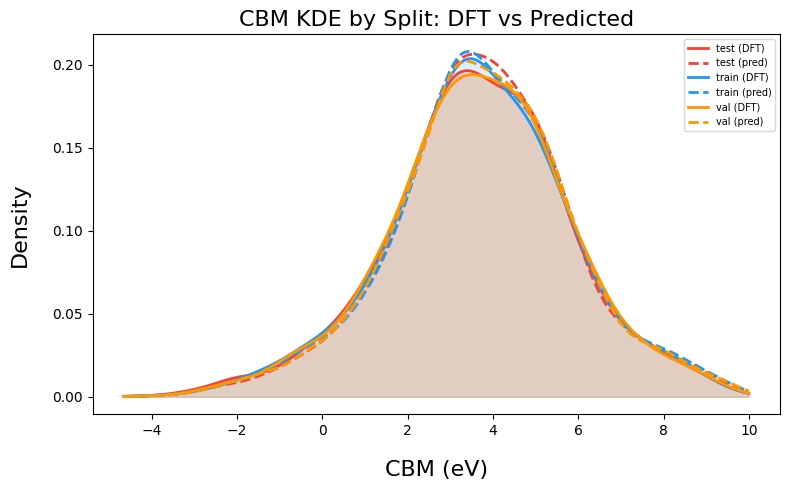

Saved: xai_kde_all.png  xai_kde_split.png


In [31]:
if df_pred is not None:
    plt.close('all')
    fig, ax = plt.subplots(figsize=(8, 5))
    for vals, color, label in [
        (df_pred['cbm_true'], 'steelblue', 'DFT Reference'),
        (df_pred['cbm_pred'], 'tomato',    'Model Predicted'),
    ]:
        ax.hist(vals, bins=60, density=True, alpha=0.35, color=color,
                label=label, edgecolor='white', lw=0.2)
        kde = gaussian_kde(vals.dropna(), bw_method=0.15)
        xr  = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(xr, kde(xr), color=color, lw=2.2)
    ax.set_xlabel('CBM (eV)', fontsize=16, labelpad=16)
    ax.set_ylabel('Density', fontsize=16, labelpad=16)
    ax.set_title('CBM Distribution: DFT vs Predicted (All Data)', fontsize=16)
    ax.legend()
    plt.tight_layout()
    plt.savefig('xai_kde_all.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Per-split KDE
    if 'split' in df_pred.columns:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(8, 5))
        pal = {'train':'#2196F3','val':'#FF9800','test':'#F44336'}
        xr  = np.linspace(df_pred['cbm_true'].min(), df_pred['cbm_true'].max(), 300)
        for split, grp in df_pred.groupby('split'):
            c = pal.get(split,'gray')
            kde_t = gaussian_kde(grp['cbm_true'].dropna(), bw_method=0.2)
            kde_p = gaussian_kde(grp['cbm_pred'].dropna(), bw_method=0.2)
            ax.fill_between(xr, kde_t(xr), alpha=0.15, color=c)
            ax.plot(xr, kde_t(xr), lw=2, color=c, label=f'{split} (DFT)')
            ax.plot(xr, kde_p(xr), lw=2, ls='--', color=c, label=f'{split} (pred)')
        ax.set_xlabel('CBM (eV)', fontsize=16, labelpad=16)
        ax.set_ylabel('Density', fontsize=16, labelpad=16)
        ax.set_title('CBM KDE by Split: DFT vs Predicted', fontsize=16)
        ax.legend(fontsize=7)
        plt.tight_layout()
        plt.savefig('xai_kde_split.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close('all')
    print('Saved: xai_kde_all.png  xai_kde_split.png')


### Visual 7 — Feature Correlation Matrix

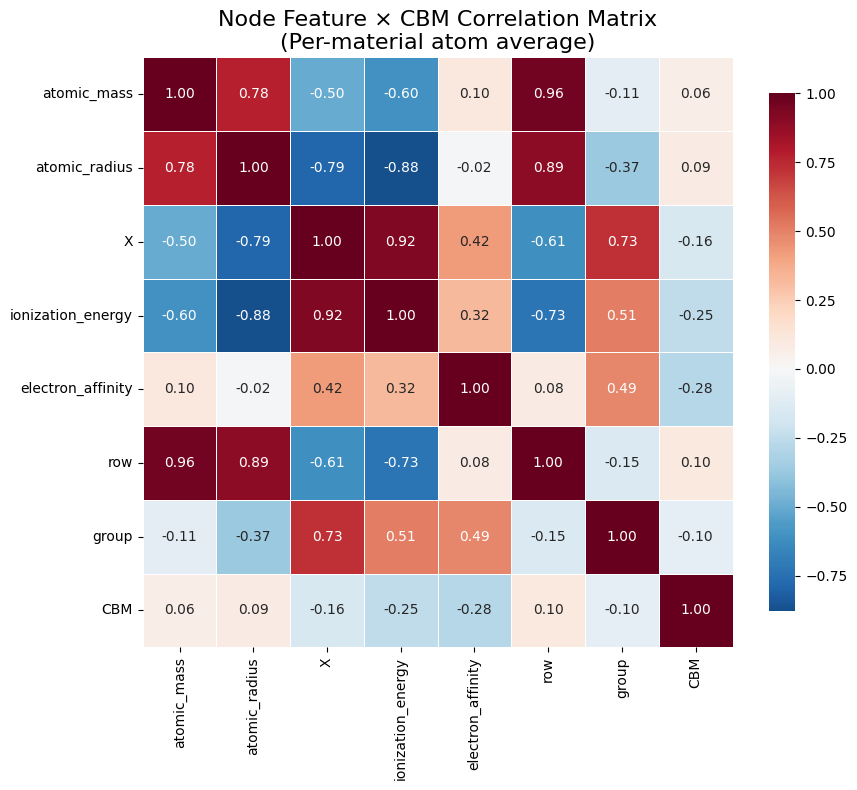

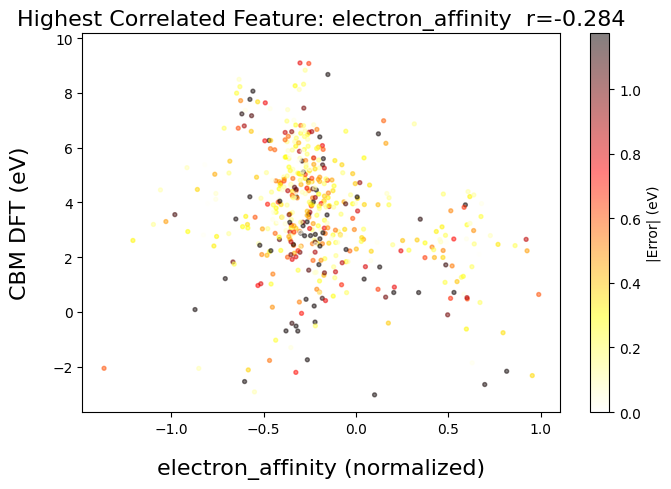

Saved: xai_feature_corr.png  xai_feature_top_corr.png


In [32]:
if df_pred is not None:
    feat_rows = []
    for fname_f in df_pred.sample(min(500,len(df_pred)), random_state=42)['filename']:
        cpath = CACHE_DIR / (fname_f.replace('.cif','')+'.pt')
        if not cpath.exists(): continue
        try:
            d = torch.load(cpath, weights_only=False)
            mf = d.x[:,:7].mean(dim=0).numpy()
            row_dict = {FEAT_NAMES[i]: mf[i] for i in range(7)}
            cbm_row  = df_pred[df_pred['filename']==fname_f]
            if len(cbm_row):
                row_dict['CBM']       = cbm_row.iloc[0]['cbm_true']
                row_dict['abs_error'] = cbm_row.iloc[0]['abs_error']
                feat_rows.append(row_dict)
        except: pass
    df_fc = pd.DataFrame(feat_rows).dropna()
    corr_mat = df_fc[FEAT_NAMES[:7]+['CBM']].corr()

    plt.close('all')
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(corr_mat, ax=ax, cmap='RdBu_r', center=0,
                annot=True, fmt='.2f', square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title('Node Feature × CBM Correlation Matrix\n(Per-material atom average)', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_feature_corr.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Top correlated feature scatter
    top_feat   = corr_mat['CBM'].drop('CBM').abs().idxmax()
    corr_val   = corr_mat.loc[top_feat, 'CBM']
    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(df_fc[top_feat], df_fc['CBM'], s=8, alpha=0.5,
                    c=df_fc['abs_error'], cmap='hot_r',
                    vmin=0, vmax=np.percentile(df_fc['abs_error'],90))
    plt.colorbar(sc, ax=ax, label='|Error| (eV)')
    ax.set_xlabel(f'{top_feat} (normalized)', fontsize=16, labelpad=16)
    ax.set_ylabel('CBM DFT (eV)', fontsize=16, labelpad=16)
    ax.set_title(f'Highest Correlated Feature: {top_feat}  r={corr_val:.3f}', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_feature_top_corr.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_feature_corr.png  xai_feature_top_corr.png')


### Visual 8 — Electronegativity × Atomic Radius Feature Space

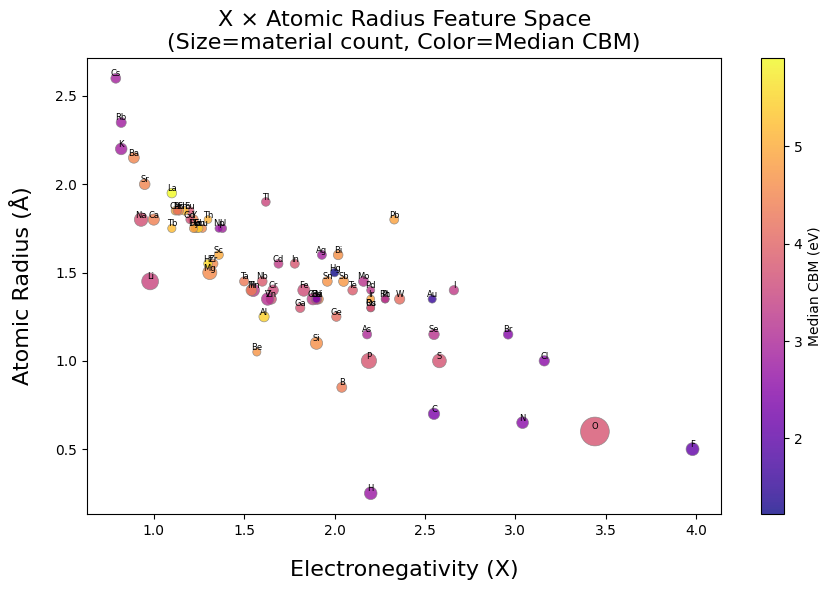

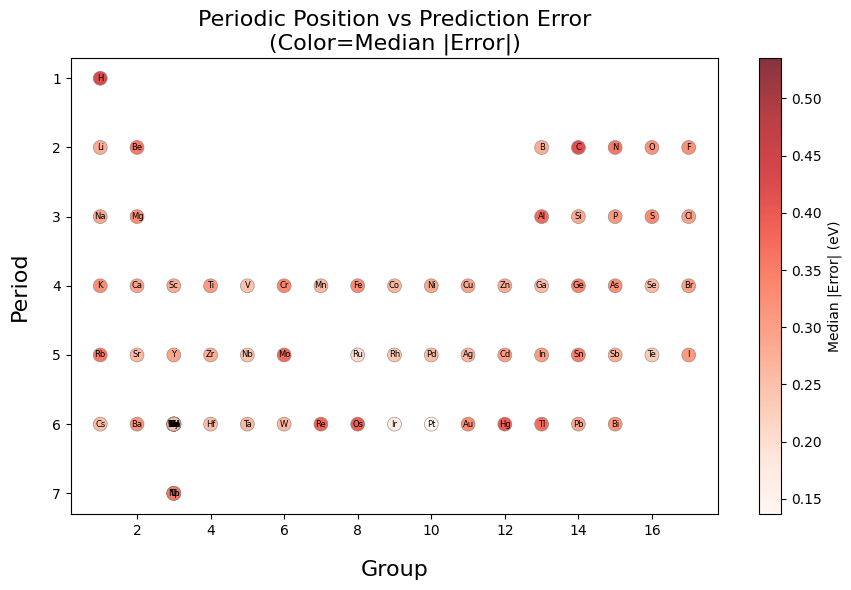

Saved: xai_feature_space.png  xai_period_error.png


In [33]:
if 'elem_stats' in dir():
    elem_phys = []
    for sym in df_elem['element'].unique():
        try:
            el = Element(sym)
            elem_phys.append({'element':sym,'X':float(el.X or 0),
                              'atomic_radius':float(el.atomic_radius or 0),
                              'row':float(el.row),'group':float(el.group)})
        except: pass
    df_phys = pd.DataFrame(elem_phys).merge(
        elem_stats[['element','median_cbm','median_abs_error','n_materials']], on='element')
    df_phys = df_phys[(df_phys['X']>0) & (df_phys['atomic_radius']>0)]

    # X vs radius colored by CBM
    plt.close('all')
    fig, ax = plt.subplots(figsize=(9, 6))
    sz = df_phys['n_materials']/df_phys['n_materials'].max()*400+30
    sc = ax.scatter(df_phys['X'], df_phys['atomic_radius'],
                    c=df_phys['median_cbm'], cmap='plasma',
                    s=sz, alpha=0.8, edgecolors='gray', lw=0.5)
    plt.colorbar(sc, ax=ax, label='Median CBM (eV)')
    for _, r in df_phys.iterrows():
        ax.annotate(r['element'], (r['X'], r['atomic_radius']),
                    fontsize=6, ha='center', va='bottom')
    ax.set_xlabel('Electronegativity (X)', fontsize=16, labelpad=16)
    ax.set_ylabel('Atomic Radius (Å)', fontsize=16, labelpad=16)
    ax.set_title('X × Atomic Radius Feature Space\n(Size=material count, Color=Median CBM)', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_feature_space.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Group vs Period colored by error
    plt.close('all')
    fig, ax = plt.subplots(figsize=(9, 6))
    sc2 = ax.scatter(df_phys['group'], df_phys['row'],
                     c=df_phys['median_abs_error'], cmap='Reds',
                     s=100, alpha=0.8, edgecolors='gray', lw=0.5)
    plt.colorbar(sc2, ax=ax, label='Median |Error| (eV)')
    for _, r in df_phys.iterrows():
        ax.annotate(r['element'], (r['group'], r['row']),
                    fontsize=6, ha='center', va='center')
    ax.set_xlabel('Group', fontsize=16, labelpad=16)
    ax.set_ylabel('Period', fontsize=16, labelpad=16)
    ax.invert_yaxis()
    ax.set_title('Periodic Position vs Prediction Error\n(Color=Median |Error|)', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_period_error.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_feature_space.png  xai_period_error.png')
else:
    print('Run Section 3 first.')


### Visual 9 — MC Dropout Uncertainty

MC Dropout uncertainty (500 materials, 20 samples)...
Ready: 500  |  std-error correlation r=0.262


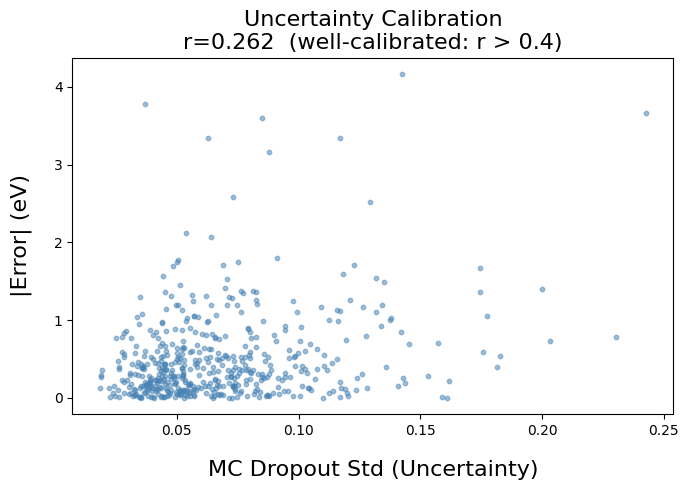

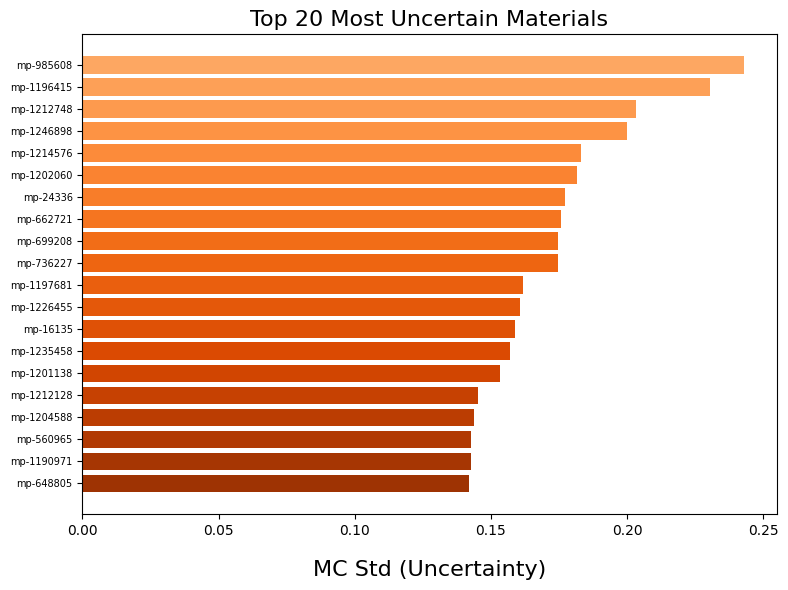

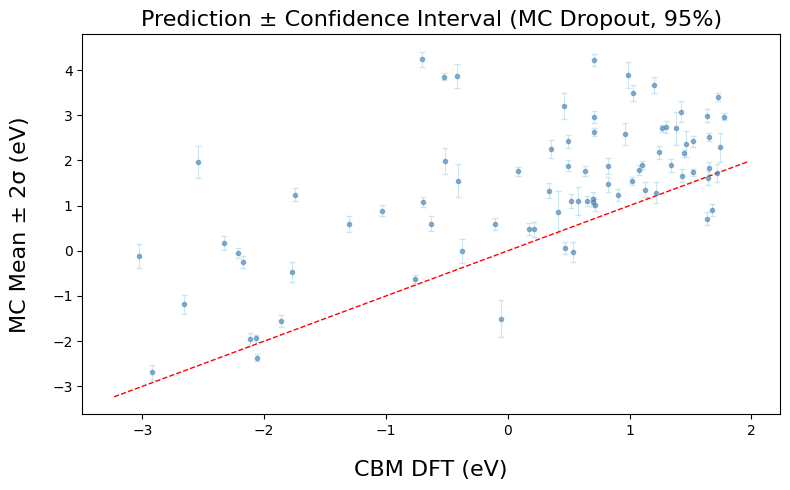

Saved: xai_mc_calibration.png  xai_mc_uncertain.png  xai_mc_ci.png


In [34]:
def mc_dropout_predict(model, batch, n=20):
    model.train()
    preds = []
    with torch.no_grad():
        for _ in range(n):
            p, _ = model(batch)
            preds.append(p.float().cpu().numpy())
    model.eval()
    arr = np.stack(preds)
    return arr.mean(0), arr.std(0)

if df_pred is not None:
    print('MC Dropout uncertainty (500 materials, 20 samples)...')
    unc_recs = []
    for _, row in df_pred.sample(min(500,len(df_pred)), random_state=42).iterrows():
        f  = row['filename']
        cp = CIF_DIR / (f if f.endswith('.cif') else f+'.cif')
        if not cp.exists(): continue
        try:
            data, _ = cif_to_data(cp, tda_scaler, filename=f)
            b = Batch.from_data_list([data.to(device)])
            m, s = mc_dropout_predict(model, b)
            unc_recs.append({'filename':f,'cbm_true':row['cbm_true'],
                             'mc_mean':float(m[0]),'mc_std':float(s[0]),
                             'abs_error':row['abs_error']})
        except: pass
    df_unc = pd.DataFrame(unc_recs)
    corr_unc = df_unc[['mc_std','abs_error']].corr().iloc[0,1]
    print(f'Ready: {len(df_unc)}  |  std-error correlation r={corr_unc:.3f}')

    # Calibration scatter
    plt.close('all')
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(df_unc['mc_std'], df_unc['abs_error'], s=10, alpha=0.5, c='steelblue')
    ax.set_xlabel('MC Dropout Std (Uncertainty)', fontsize=16, labelpad=16)
    ax.set_ylabel('|Error| (eV)', fontsize=16, labelpad=16)
    ax.set_title(f'Uncertainty Calibration\nr={corr_unc:.3f}  (well-calibrated: r > 0.4)', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_mc_calibration.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Top 20 most uncertain
    plt.close('all')
    fig, ax = plt.subplots(figsize=(8, 6))
    tu = df_unc.nlargest(20,'mc_std').reset_index(drop=True)
    ax.barh(range(len(tu)), tu['mc_std'],
            color=plt.cm.Oranges(np.linspace(0.4,0.9,len(tu))))
    ax.set_yticks(range(len(tu)))
    ax.set_yticklabels([f.replace('.cif','')[:14] for f in tu['filename']], fontsize=7)
    ax.set_xlabel('MC Std (Uncertainty)', fontsize=16, labelpad=16)
    ax.set_title('Top 20 Most Uncertain Materials', fontsize=16)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('xai_mc_uncertain.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    # Prediction ± CI errorbar
    plt.close('all')
    fig, ax = plt.subplots(figsize=(8, 5))
    pl = df_unc.sort_values('cbm_true').head(80)
    ax.errorbar(pl['cbm_true'], pl['mc_mean'], yerr=2*pl['mc_std'],
                fmt='o', ms=3, alpha=0.6, elinewidth=0.8, capsize=2,
                color='steelblue', ecolor='lightblue')
    xlim = [pl['cbm_true'].min()-0.2, pl['cbm_true'].max()+0.2]
    ax.plot(xlim, xlim, 'r--', lw=1)
    ax.set_xlabel('CBM DFT (eV)', fontsize=16, labelpad=16)
    ax.set_ylabel('MC Mean ± 2σ (eV)', fontsize=16, labelpad=16)
    ax.set_title('Prediction ± Confidence Interval (MC Dropout, 95%)', fontsize=16)
    plt.tight_layout()
    plt.savefig('xai_mc_ci.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_mc_calibration.png  xai_mc_uncertain.png  xai_mc_ci.png')


### Visual 10 — Learning Curve

In [35]:
RUN_LEARNING_CURVE = False  # Set True to run (~10-30 min)
if RUN_LEARNING_CURVE:
    from torch.optim import AdamW
    all_cache = [p for p in CACHE_DIR.glob('*.pt') if not p.name.startswith('cache') and p.suffix=='.pt']
    fracs     = [0.05, 0.1, 0.2, 0.4, 0.7, 1.0]
    lc_res    = []
    for frac in fracs:
        n  = max(50, int(len(all_cache)*frac))
        tr = all_cache[:int(0.8*n)]; va = all_cache[int(0.8*n):n]
        m  = CBMPredictor().to(device)
        op = AdamW(m.parameters(), lr=1e-3)
        from torch_geometric.loader import DataLoader as DL
        class DS(torch.utils.data.Dataset):
            def __init__(self,p): self.p=p
            def __len__(self): return len(self.p)
            def __getitem__(self,i):
                d=torch.load(self.p[i],weights_only=False)
                if not hasattr(d,'megnet'): d.megnet=torch.zeros(MEGNET_EMB_DIM)
                return d
        for ep in range(30):
            m.train()
            for batch in DL(DS(tr), batch_size=64, shuffle=True, num_workers=0):
                batch=batch.to(device)
                pred,_=m(batch); cbm=batch.cbm.view(-1)
                if not(torch.isfinite(pred).all() and torch.isfinite(cbm).all()): continue
                loss=F.mse_loss(pred.float(),cbm.float())
                op.zero_grad(); loss.backward(); op.step()
        m.eval(); ps,ts=[],[]
        with torch.no_grad():
            for batch in DL(DS(va), batch_size=64, num_workers=0):
                batch=batch.to(device); pred,_=m(batch)
                p=pred.float().cpu().numpy(); t=batch.cbm.view(-1).cpu().numpy()
                mask=np.isfinite(p)&np.isfinite(t)
                ps.extend(p[mask]); ts.extend(t[mask])
        if len(ps)>5:
            lc_res.append({'n_train':len(tr),'val_mae':mean_absolute_error(ts,ps)})
            print(f'  frac={frac:.0%}  n={len(tr)}  MAE={lc_res[-1]["val_mae"]:.4f}')
    df_lc = pd.DataFrame(lc_res)
    plt.close('all')
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df_lc['n_train'], df_lc['val_mae'], 'o-', lw=2, ms=8, color='steelblue')
    ax.set_xscale('log')
    ax.set_xlabel('Training Set Size', fontsize=16, labelpad=16)
    ax.set_ylabel('Val MAE (eV)', fontsize=16, labelpad=16)
    ax.set_title('Learning Curve — MAE vs Training Set Size', fontsize=16)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('xai_learning_curve.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')
    print('Saved: xai_learning_curve.png')
else:
    print('Learning curve skipped. Set RUN_LEARNING_CURVE=True to run.')


Learning curve skipped. Set RUN_LEARNING_CURVE=True to run.


---
## 💾 All Output Files

### Section 4 — Error Analysis
| File | Content |
|------|---------|
| `xai_parity.png` | Parity plot (colored by split) |
| `xai_error_dist.png` | Error distribution histogram |
| `xai_error_vs_cbm.png` | |Error| vs CBM magnitude |
| `xai_error_split.png` | Error boxplot by split |

### Section 3 — Element Statistics
| File | Content |
|------|---------|
| `xai_element_cbm.png` | Median CBM by element |
| `xai_element_error.png` | Median error by element |
| `xai_element_bias.png` | Systematic over/under prediction |

### Section 2 — Integrated Gradients
| File | Content |
|------|---------|
| `xai_feature_importance.png` | Global node feature importance (7 features) |
| `xai_atom_importance.png` | Per-atom importance bar |
| `xai_atom_ig_map.png` | Feature × Atom attribution heatmap |

### Section 1 — GNNExplainer
| File | Content |
|------|---------|
| `xai_gnnexplainer_atoms.png` | Atom importance bar |
| `xai_gnnexplainer_edges.png` | Edge mask distribution |
| `xai_crystal_map.png` | Crystal structure importance map |
| `xai_gnnexplainer_elements.png` | Bulk element importance |

### Section 5 — MEGNet Embedding Branch *(new)*
| File | Content |
|------|---------|
| `xai_branch_norms.png` | GNN vs TDA vs MEGNet branch activation norms |
| `xai_emb_umap_cbm.png` | UMAP of projected emb space — CBM |
| `xai_emb_umap_error.png` | UMAP of projected emb space — Error |
| `xai_emb_dim_corr.png` | Per-dimension correlation with CBM |
| `xai_emb_top_dim.png` | Most predictive embedding dimension vs CBM |
| `xai_branch_ablation.png` | With vs without MEGNet branch MAE |

### Section 6 — Literature Visuals
| File | Source | Content |
|------|--------|---------|
| `xai_2d_hist_all.png` | CGCNN | 2D density histogram |
| `xai_2d_hist_test.png` | CGCNN | Test set density histogram |
| `xai_umap_full_cbm.png` | MEGNet/S-CGCNN | Full latent UMAP — CBM |
| `xai_umap_full_error.png` | MEGNet/S-CGCNN | Full latent UMAP — Error |
| `xai_periodic_cbm.png` | Masuda 2024 | Periodic table — median CBM |
| `xai_periodic_bias.png` | Masuda 2024 | Periodic table — bias |
| `xai_periodic_error.png` | Masuda 2024 | Periodic table — median error |
| `xai_crystal_cbm.png` | SEN 2023 | Crystal system vs CBM |
| `xai_crystal_error.png` | SEN 2023 | Crystal system vs error |
| `xai_dist_vs_cbm.png` | GeoCGNN | Bond distance vs CBM |
| `xai_natoms_vs_error.png` | PSCG-Net | Atom count vs error |
| `xai_mindist_vs_cbm.png` | GeoCGNN | Min bond distance vs CBM |
| `xai_coordination.png` | GeoCGNN | Coordination number dist. |
| `xai_kde_all.png` | CTGNN | KDE: DFT vs predicted |
| `xai_kde_split.png` | CTGNN | KDE by split |
| `xai_feature_corr.png` | EGIN/ACGNet | Feature correlation matrix |
| `xai_feature_top_corr.png` | EGIN/ACGNet | Top correlated feature |
| `xai_feature_space.png` | Masuda 2024 | X × radius feature space |
| `xai_period_error.png` | Masuda 2024 | Period position vs error |
| `xai_mc_calibration.png` | Ensemble GCN | Uncertainty calibration |
| `xai_mc_uncertain.png` | Ensemble GCN | Most uncertain materials |
| `xai_mc_ci.png` | Ensemble GCN | Prediction ± CI |
| `xai_learning_curve.png` | CGCNN | Learning curve |

In [36]:
print('XAI analizi tamamlandı! (v2 mimarisine uyarlandı)')
print('\nOluşturulan PNG dosyaları:')
for f in sorted(Path('.').glob('xai_*.png')):
    print(f'  {f.name:45s} {f.stat().st_size/1024:.0f} KB')


XAI analysis complete!

Generated PNG files:
  xai_2d_hist_all.png                           74 KB
  xai_2d_hist_test.png                          74 KB
  xai_atom_ig_map.png                           51 KB
  xai_atom_importance.png                       42 KB
  xai_branch_norms.png                          46 KB
  xai_coordination.png                          34 KB
  xai_crystal_cbm.png                           58 KB
  xai_crystal_error.png                         59 KB
  xai_dist_vs_cbm.png                           137 KB
  xai_element_bias.png                          63 KB
  xai_element_cbm.png                           52 KB
  xai_element_error.png                         52 KB
  xai_emb_dim_corr.png                          60 KB
  xai_emb_top_dim.png                           183 KB
  xai_emb_umap_cbm.png                          219 KB
  xai_emb_umap_error.png                        184 KB
  xai_error_dist.png                            39 KB
  xai_error_split.png            